# Pipeline Avançado: Ensemble de Seleção + Ensemble de Modelos

**Etapa 0** — Baseline (todos os features, sem seleção)  
**Etapa 1** — Ensemble de Seleção de Features (voting / ranking / stability)  
**Etapa 2** — Ensemble de Modelos por dataset (Voting soft+hard · Stacking com OOF)

Modelos base: RandomForest · XGBoost · DecisionTree · GaussianNB (calibrado) · KNN · GradientBoosting  
Meta-modelo (Stacking): LogisticRegression treinado sobre OOF predictions

In [1]:
# ── Padrão ───────────────────────────────────────────────────────
import warnings
from collections import defaultdict, Counter
from pathlib import Path
from statistics import mode as stat_mode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

# ── Scikit-learn ─────────────────────────────────────────────────
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier, StackingClassifier, VotingClassifier,
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    matthews_corrcoef, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

# ── Optuna ───────────────────────────────────────────────────────
import optuna

# ── XGBoost (opcional) ───────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost não disponível. Instale com: pip install xgboost")

# ── mRMR (opcional) ──────────────────────────────────────────────
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️  mRMR não disponível. Instale com: pip install mrmr-selection")

# ── Configurações globais ─────────────────────────────────────────
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
print("✅ Imports carregados.")


✅ Imports carregados.


## Pré-processamento

IQR capping → remoção de colunas irrelevantes → encode do label.

In [2]:
DATA_PATH = Path("../data/processed/DoS_with_gap_features.csv")
df = pd.read_csv(DATA_PATH)
print(f"Shape original: {df.shape}")

def cap_outliers_iqr(df, columns):
    df_out = df.copy()
    for col in columns:
        q1, q3 = df_out[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_out[col] = df_out[col].clip(lower=q1 - 1.5*iqr, upper=q3 + 1.5*iqr)
    return df_out

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_tratado = cap_outliers_iqr(df, numeric_cols)

COLUNAS_REMOVER = [
    "frame.time_delta_displayed","frame.time_epoch","frame.time_invalid",
    "frame.time_relative","tcp.srcport","tcp.dstport",
    "frame.coloring_rule.name","frame.coloring_rule.string",
    "frame.comment","frame.comment.expert","frame.encap_type",
    "frame.file_off","frame.ignored","frame.incomplete",
    "frame.interface_id","frame.interface_name","frame.link_nr",
    "frame.marked","frame.md5_hash","frame.number","frame.offset_shift",
    "mqtt.msgid","mqtt.username","mqtt.passwd","mqtt.willmsg","mqtt.willtopic",
]

num_df = df_tratado.select_dtypes(include=["int64","float64"])
X = num_df.drop(columns=[c for c in COLUNAS_REMOVER if c in num_df.columns], errors="ignore")
X = X.fillna(0).replace([np.inf, -np.inf], 0)

le = LabelEncoder()
y = le.fit_transform(df_tratado["type"])

print(f"Features: {X.shape[1]} | Amostras: {X.shape[0]}")
print(f"Classes: {le.classes_}  →  {dict(enumerate(le.classes_))}")


Shape original: (94625, 67)
Features: 29 | Amostras: 94625
Classes: ['DoS' 'normal']  →  {0: 'DoS', 1: 'normal'}


## Etapa 0 — Baseline (todos os features, sem seleção)

Split 70/30 estratificado. Sem Optuna — hiperparâmetros razoáveis fixos.  
Serve como referência para comparar o ganho das etapas seguintes.

Treinando modelos baseline…
  ✓ RandomForest          F1=0.9670  LogLoss=0.26702
  ✓ XGBoost               F1=0.9705  LogLoss=0.07812
  ✓ DecisionTree          F1=0.9643  LogLoss=0.58607
  ✓ GaussianNB_Cal        F1=0.9268  LogLoss=0.23611
  ✓ KNN                   F1=0.9654  LogLoss=0.35733
  ✓ GradientBoosting      F1=0.9679  LogLoss=0.08725

── Métricas Etapa 0 — Baseline ──────────────────────────


,accuracy,precision,recall,f1_macro,mcc,log_loss
model,,,,,,
RandomForest,0.96713,0.96773,0.96664,0.96705,0.93437,0.26702
XGBoost,0.97055,0.97147,0.96992,0.97047,0.94139,0.07812
DecisionTree,0.96435,0.96439,0.96421,0.96429,0.92860,0.58607
GaussianNB_Cal,0.92754,0.93575,0.92510,0.92682,0.86078,0.23611
KNN,0.96551,0.96580,0.96519,0.96544,0.93099,0.35733
GradientBoosting,0.96805,0.96927,0.96730,0.96795,0.93657,0.08725
Voting_Soft,0.97016,0.97132,0.96944,0.97007,0.94076,0.09108


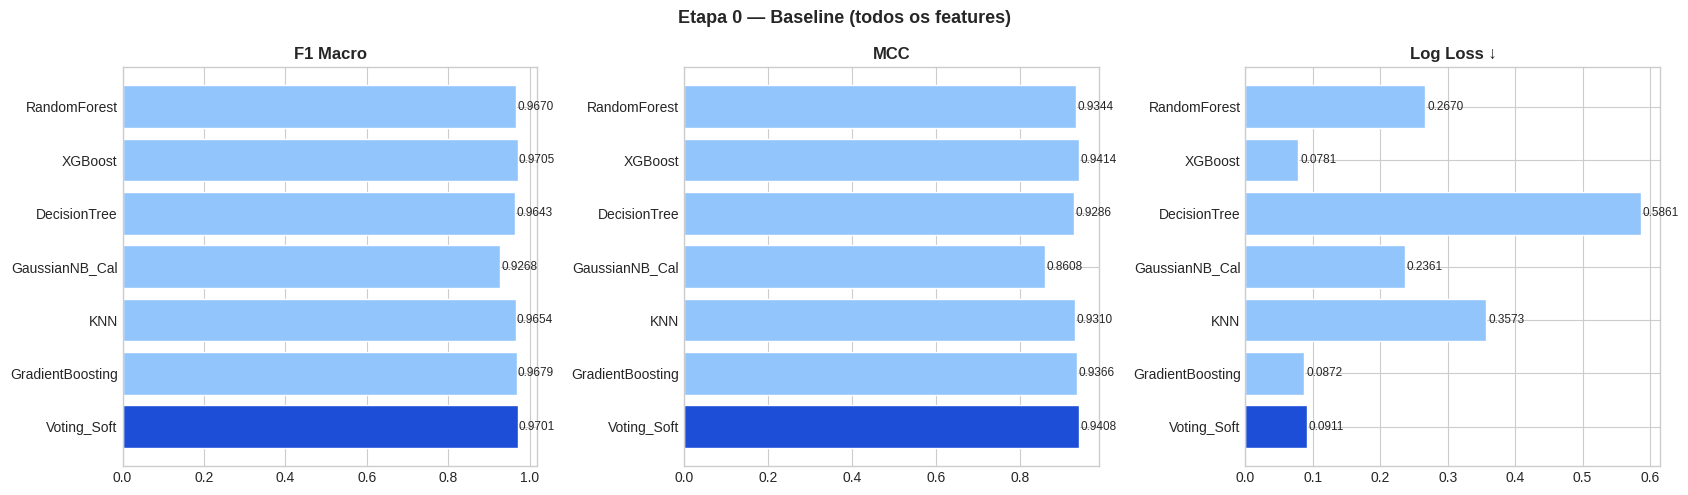


🏆 Melhor baseline: XGBoost  F1=0.97047


In [3]:
# ── Split 70/30 ──────────────────────────────────────────────────
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

def _metrics(model, X_te, y_te, name):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te) if hasattr(model, "predict_proba") else None
    ll = log_loss(y_te, y_proba) if y_proba is not None else np.nan
    return {
        "model":     name,
        "accuracy":  round(accuracy_score(y_te, y_pred), 5),
        "precision": round(precision_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "recall":    round(recall_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "f1_macro":  round(f1_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "mcc":       round(matthews_corrcoef(y_te, y_pred), 5),
        "log_loss":  round(ll, 5) if np.isfinite(ll) else np.nan,
    }

BASELINE_MODELS = {
    "RandomForest":     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":          XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                      verbosity=0, eval_metric="logloss") if XGBOOST_AVAILABLE
                        else RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "DecisionTree":     DecisionTreeClassifier(random_state=42),
    # cv=3 no lugar de cv=5: 3 folds suficientes para calibracao, 40%% mais rapido
    "GaussianNB_Cal":   CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=3),
    # algorithm="kd_tree": indexa espacialmente os vizinhos, predict 5-20x mais rapido
    "KNN":              KNeighborsClassifier(n_neighbors=7, n_jobs=-1, algorithm="kd_tree"),
    # HistGBT max_iter=50: suficiente para baseline, 2x mais rapido que 100
    "GradientBoosting": HistGradientBoostingClassifier(max_iter=50, learning_rate=0.1,
                                                       max_depth=4, random_state=42),
}

print("Treinando modelos baseline…")
baseline_rows, baseline_trained = [], {}
for name, model in BASELINE_MODELS.items():
    model.fit(X_tr_b, y_tr_b)
    baseline_trained[name] = model
    row = _metrics(model, X_te_b, y_te_b, name)
    baseline_rows.append(row)
    print(f"  ✓ {name:20s}  F1={row['f1_macro']:.4f}  LogLoss={row['log_loss']}")

# ── Voting soft ──────────────────────────────────────────────────
# Removido VotingClassifier Hard: produz resultados muito próximos ao Soft
# e custa um retreinamento completo de todos os modelos (~2 min extras).
# O Hard sera avaliado propriamente na Etapa 2 com CV.
vc_s = VotingClassifier(list(baseline_trained.items()), voting="soft", n_jobs=-1)
vc_s.fit(X_tr_b, y_tr_b)
baseline_rows.append(_metrics(vc_s, X_te_b, y_te_b, "Voting_Soft"))

# ── Stacking: avaliado na Etapa 2 com CV completo ────────────────
# Removido do baseline: StackingClassifier(cv=3) treina todos os modelos
# 4x cada (3 folds OOF + 1 refit final), adicionando ~5-8 min ao baseline
# por um resultado que sera obtido com mais rigor na Etapa 2.
# O baseline se foca nos modelos individuais + Voting Soft como referencia.

df_baseline = pd.DataFrame(baseline_rows).set_index("model")
print("\n── Métricas Etapa 0 — Baseline ──────────────────────────")
display(df_baseline)

# ── Gráfico ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ENSEMBLE_NAMES = {"Voting_Soft"}
colors_b = ["#1D4ED8" if m in ENSEMBLE_NAMES else "#93C5FD" for m in df_baseline.index]
for ax, col, lbl in zip(axes, ["f1_macro","mcc","log_loss"],
                                ["F1 Macro","MCC","Log Loss ↓"]):
    bars = ax.barh(df_baseline.index, df_baseline[col], color=colors_b, edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(lbl, fontweight="bold")
    for bar, v in zip(bars, df_baseline[col]):
        ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                f"{v:.4f}" if np.isfinite(v) else "N/A", va="center", fontsize=8.5)
plt.suptitle("Etapa 0 — Baseline (todos os features)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

best_b = df_baseline["f1_macro"].idxmax()
print(f"\n🏆 Melhor baseline: {best_b}  F1={df_baseline.loc[best_b,'f1_macro']:.5f}")


## Etapa 1 — Ensemble de Seleção de Features

Cada seletor é aplicado sobre **todo o X** (sem CV — apenas para geração de datasets).  
Agregação por três estratégias:

| Estratégia | Descrição |
|---|---|
| **Voting count** | Nº de seletores que escolheram a feature |
| **Mean rank** | Posição média nos rankings de cada seletor (menor = melhor) |
| **Consensus majority** | Features em ≥ metade dos seletores |

Datasets gerados: um por seletor individual + `consensus_majority` + `consensus_top15_rank`.

In [4]:
# ── Parâmetros de seleção ─────────────────────────────────────────
K_MRMR=K_FISHER=K_PEARSON=K_TREE=K_SVC=K_LASSO = 15

# ── Fisher Score ─────────────────────────────────────────────────
def fisher_score(X, y):
    classes      = np.unique(y)
    overall_mean = X.mean(axis=0).values
    scores       = np.zeros(X.shape[1])
    for i in range(X.shape[1]):
        vals = X.iloc[:, i].values
        bet, wit = 0.0, 0.0
        for c in classes:
            mask = y == c; nc = mask.sum()
            if nc > 0:
                mu_c = vals[mask].mean()
                bet += nc * (mu_c - overall_mean[i])**2
                wit += nc * vals[mask].var()
        scores[i] = bet / wit if wit > 1e-10 else 0.0
    return scores

# ── Funções de seleção ───────────────────────────────────────────
def _selector_functions():
    def sel_mrmr(X_tr, y_tr):
        if not MRMR_AVAILABLE: return []
        try: return mrmr_classif(X_tr, y_tr, K=min(K_MRMR, X_tr.shape[1]))
        except Exception as e: print(f"[mRMR] {e}"); return []

    def sel_fisher(X_tr, y_tr):
        sc = fisher_score(X_tr, y_tr)
        return (pd.DataFrame({"f": X_tr.columns,"s": sc})
                .sort_values("s", ascending=False)
                .head(min(K_FISHER, len(X_tr.columns)))["f"].tolist())

    def sel_pearson(X_tr, y_tr):
        ac = X_tr.apply(lambda c: abs(np.corrcoef(c, y_tr)[0,1])).fillna(0)
        return ac.sort_values(ascending=False).head(min(K_PEARSON,len(ac))).index.tolist()

    def sel_extratrees(X_tr, y_tr):
        et = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
        et.fit(X_tr, y_tr)
        imp = pd.Series(et.feature_importances_, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(min(K_TREE,X_tr.shape[1])).index.tolist()

    def sel_svc(X_tr, y_tr):
        Xs = StandardScaler().fit_transform(X_tr)
        svc = LinearSVC(C=0.1, penalty="l1", dual=False, max_iter=5000, random_state=42)
        svc.fit(Xs, y_tr)
        coef = np.mean(np.abs(svc.coef_),axis=0) if svc.coef_.ndim>1 else np.abs(svc.coef_[0])
        return pd.Series(coef, index=X_tr.columns).sort_values(ascending=False).head(min(K_SVC,X_tr.shape[1])).index.tolist()

    def sel_lasso(X_tr, y_tr):
        Xs = StandardScaler().fit_transform(X_tr)
        lasso = LassoCV(cv=3, random_state=42, max_iter=10000, n_jobs=-1)
        lasso.fit(Xs, y_tr)
        return pd.Series(np.abs(lasso.coef_), index=X_tr.columns).sort_values(ascending=False).head(min(K_LASSO,X_tr.shape[1])).index.tolist()

    def sel_lowvar(X_tr, y_tr):
        sel = VarianceThreshold(threshold=0.0); sel.fit(X_tr)
        return X_tr.columns[sel.get_support(indices=True)].tolist()

    return {"mRMR":sel_mrmr,"Fisher":sel_fisher,"Pearson":sel_pearson,
            "ExtraTrees":sel_extratrees,"LinearSVC_L1":sel_svc,
            "LassoCV":sel_lasso,"LowVariance":sel_lowvar}

selector_funcs = _selector_functions()
print("Seletores:", list(selector_funcs.keys()))

# ── Aplica todos os seletores sobre X completo ───────────────────
print("\nAplicando seletores sobre X completo…")
raw_selections = {}   # {selector: [ranked feature list]}
for sel_name, sel_fn in selector_funcs.items():
    cols = sel_fn(X, y)
    raw_selections[sel_name] = cols
    print(f"  {sel_name:15s} → {len(cols)} features")

# ── Tabela de rankings (posição de cada feature por seletor) ──────
all_features = X.columns.tolist()
n_sel = len(raw_selections)
PENALTY = max(len(v) for v in raw_selections.values()) + 1  # rank para não-selecionadas

rank_data = {}
for sel_name, cols in raw_selections.items():
    ranks = {}
    for pos, feat in enumerate(cols):
        ranks[feat] = pos + 1          # rank 1-based (1 = melhor)
    for feat in all_features:
        if feat not in ranks:
            ranks[feat] = PENALTY      # não selecionada → penalidade
    rank_data[sel_name] = ranks

df_ranks = pd.DataFrame(rank_data).loc[all_features]  # features × seletores

# ── Métricas de agregação ─────────────────────────────────────────
df_ranks["voting_count"] = (df_ranks < PENALTY).sum(axis=1)
df_ranks["mean_rank"]    = df_ranks[list(raw_selections.keys())].mean(axis=1)
df_ranks = df_ranks.sort_values(["voting_count","mean_rank"], ascending=[False,True])

print("\n── Top 20 features por consenso ─────────────────────────")
display(df_ranks[["voting_count","mean_rank"]].head(20))

# ── Gera os datasets ──────────────────────────────────────────────
selector_datasets = {}

# Um dataset por seletor individual
for sel_name, cols in raw_selections.items():
    if cols:
        selector_datasets[sel_name] = X[cols].copy()

# Consensus: majority (>= metade dos seletores)
majority_thresh = n_sel // 2
consensus_maj_cols = df_ranks[df_ranks["voting_count"] >= majority_thresh].index.tolist()
selector_datasets["consensus_majority"] = X[consensus_maj_cols].copy()

# Consensus: top 15 por mean_rank
consensus_rank_cols = df_ranks.sort_values("mean_rank").head(15).index.tolist()
selector_datasets["consensus_top15_rank"] = X[consensus_rank_cols].copy()

print(f"\nDatasets gerados ({len(selector_datasets)}):")
for k, v in selector_datasets.items():
    print(f"  {k:25s} → {v.shape[1]} features: {v.columns.tolist()}")


Seletores: ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC_L1', 'LassoCV', 'LowVariance']

Aplicando seletores sobre X completo…


100%|██████████| 14/14 [00:03<00:00,  4.50it/s]


  mRMR            → 14 features
  Fisher          → 15 features
  Pearson         → 15 features
  ExtraTrees      → 15 features
  LinearSVC_L1    → 15 features
  LassoCV         → 15 features
  LowVariance     → 14 features

── Top 20 features por consenso ─────────────────────────


,voting_count,mean_rank
mqtt.len,7,2.571429
mqtt.topic_len,7,3.857143
frame.time_delta,7,4.571429
frame.len,7,5.000000
frame.cap_len,7,5.428571
mqtt.conack.flags.reserved,7,7.000000
mqtt.clientid_len,7,7.428571
mqtt.conack.flags.sp,7,9.428571
mqtt.conack.val,7,9.428571
mqtt.conflag.cleansess,7,10.857143



Datasets gerados (9):
  mRMR                      → 14 features: ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.conack.flags.reserved', 'mqtt.clientid_len', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conack.flags.sp', 'mqtt.kalive', 'connect_gap', 'publish_gap']
  Fisher                    → 15 features: ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.len', 'frame.cap_len', 'frame.time_delta', 'mqtt.conack.flags.reserved', 'mqtt.conack.val', 'mqtt.conack.flags.sp', 'mqtt.clientid_len', 'mqtt.kalive', 'mqtt.conflag.cleansess', 'connect_gap', 'publish_gap', 'mqtt.conflag.uname']
  Pearson                   → 15 features: ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.len', 'frame.cap_len', 'frame.time_delta', 'mqtt.conack.flags.reserved', 'mqtt.conack.val', 'mqtt.conack.flags.sp', 'mqtt.clientid_len', 'mqtt.kalive', 'mqtt.conflag.cleansess', 'connect_gap', 'publish_gap', 'mqtt.conflag.uname']
  ExtraTrees      

### Visualizações — Ensemble de Seleção

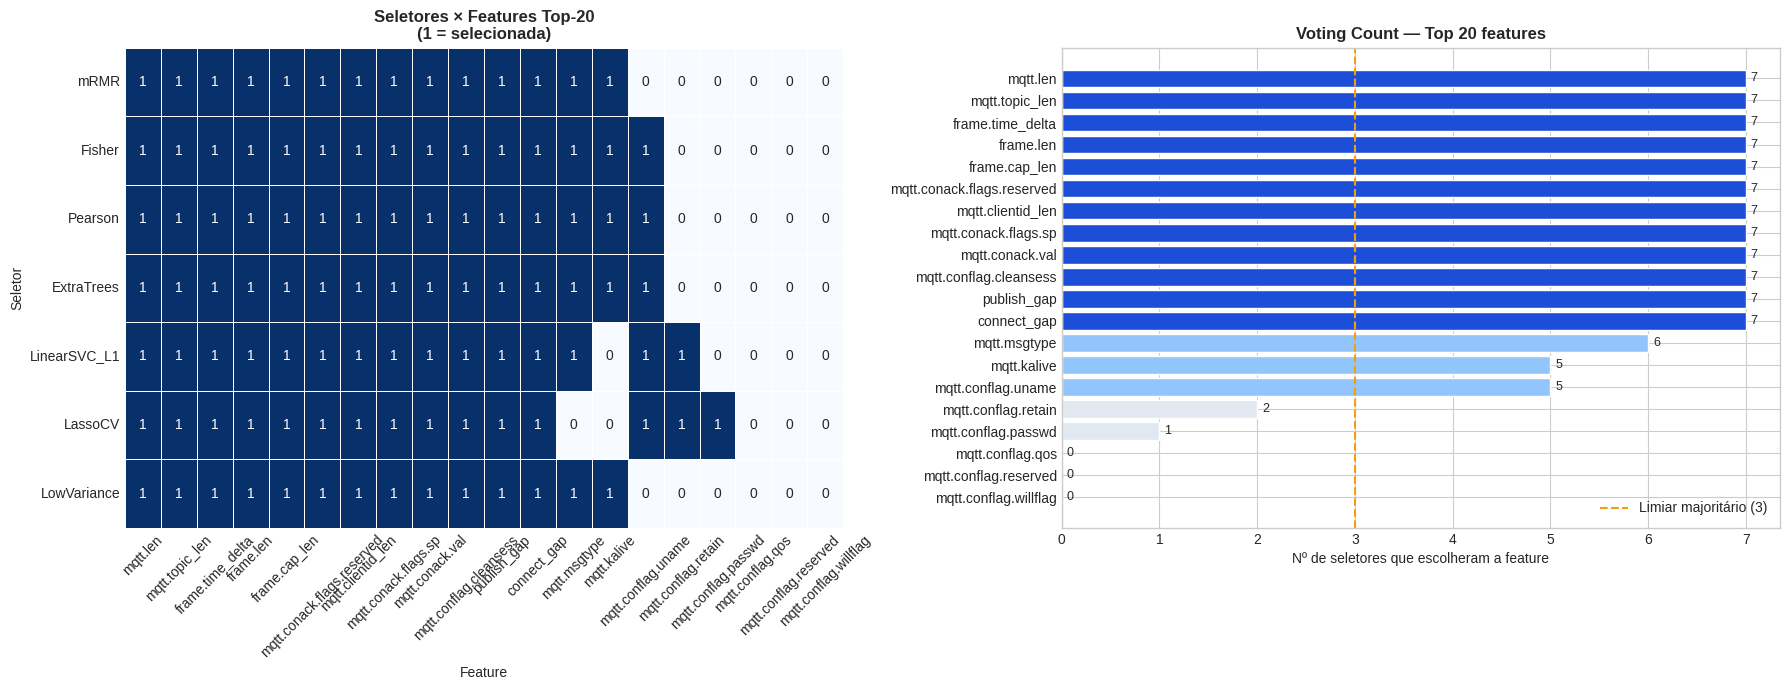

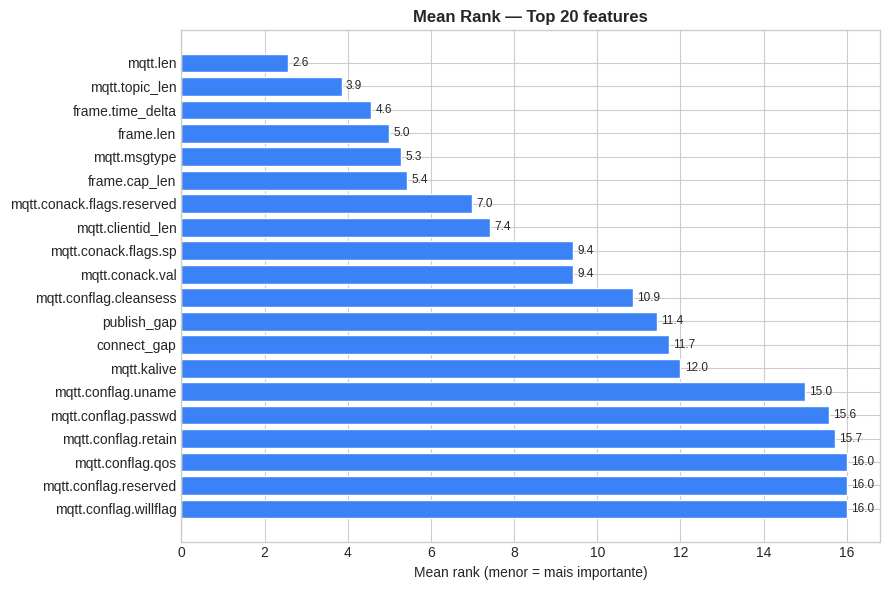

In [5]:
# ── 1. Heatmap: seletores × features (top 20 por voting_count) ──
top20 = df_ranks.head(20).index.tolist()
heat_data = df_ranks.loc[top20, list(raw_selections.keys())]
# Mascara: 1 se selecionada (rank < PENALTY), 0 caso contrário
heat_binary = (heat_data < PENALTY).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap de presença (binário)
sns.heatmap(heat_binary.T, annot=True, fmt="d", cmap="Blues",
            cbar=False, linewidths=0.5, ax=axes[0])
axes[0].set_title("Seletores × Features Top-20\n(1 = selecionada)", fontweight="bold")
axes[0].set_xlabel("Feature"); axes[0].set_ylabel("Seletor")
axes[0].tick_params(axis='x', rotation=45)

# Bar chart: voting count para top 20
vc = df_ranks.loc[top20, "voting_count"]
colors_vc = ["#1D4ED8" if v == n_sel else "#93C5FD" if v >= majority_thresh else "#E2E8F0"
             for v in vc]
axes[1].barh(top20, vc, color=colors_vc, edgecolor="white")
axes[1].invert_yaxis()
axes[1].axvline(majority_thresh, color="#F59E0B", linewidth=1.5, linestyle="--",
                label=f"Limiar majoritário ({majority_thresh})")
axes[1].set_xlabel("Nº de seletores que escolheram a feature")
axes[1].set_title("Voting Count — Top 20 features", fontweight="bold")
axes[1].legend(); 
for i, v in enumerate(vc):
    axes[1].text(v+0.05, i, str(int(v)), va="center", fontsize=9)

plt.tight_layout(); plt.show()

# ── 2. Mean rank por feature (top 20) ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
mr = df_ranks.loc[top20, "mean_rank"].sort_values()
ax.barh(mr.index, mr.values, color="#3B82F6", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Mean rank (menor = mais importante)")
ax.set_title("Mean Rank — Top 20 features", fontweight="bold")
for i, v in enumerate(mr.values):
    ax.text(v+0.1, i, f"{v:.1f}", va="center", fontsize=8.5)
plt.tight_layout(); plt.show()


## Etapa 2 — Ensemble de Modelos com Optuna (por dataset de features)

Para cada dataset da Etapa 1, o pipeline executa:

1. **Optuna** (paralelo, 1 thread por modelo) — tuna RF, XGBoost, DT, GNB, KNN, GB
2. **VotingClassifier Soft** — média de probabilidades
3. **VotingClassifier Hard** — votação majoritária
4. **StackingClassifier** — base models com OOF predictions → meta-model LogisticRegression

CV externo: 5-fold estratificado. CV interno (Optuna): 3-fold sobre `X_tr`.

In [6]:
def _to_array(X):
    return X.values if isinstance(X, pd.DataFrame) else X

# ── RandomForest ─────────────────────────────────────────────────
def _obj_rf(trial, X_tr, y_tr):
    p = {"n_estimators": trial.suggest_int("n_estimators", 50, 400, step=50),
         "max_depth":    trial.suggest_categorical("max_depth", [None, 5, 10, 20, 30]),
         "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
         "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
         "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
         "bootstrap":    trial.suggest_categorical("bootstrap", [True, False]),
         "random_state": 42, "n_jobs": -1}
    return cross_val_score(RandomForestClassifier(**p), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── XGBoost ──────────────────────────────────────────────────────
def _obj_xgb(trial, X_tr, y_tr):
    p = {"n_estimators":     trial.suggest_int("n_estimators", 50, 400, step=50),
         "max_depth":        trial.suggest_int("max_depth", 2, 10),
         "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
         "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
         "gamma":            trial.suggest_float("gamma", 0.0, 1.0),
         "reg_alpha":        trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True),
         "reg_lambda":       trial.suggest_float("reg_lambda", 1e-5, 1.0, log=True),
         "random_state": 42, "n_jobs": -1,
         "verbosity": 0, "eval_metric": "logloss"}
    mdl = XGBClassifier(**p) if XGBOOST_AVAILABLE else RandomForestClassifier(random_state=42, n_jobs=-1)
    return cross_val_score(mdl, _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── DecisionTree ─────────────────────────────────────────────────
def _obj_dt(trial, X_tr, y_tr):
    p = {"max_depth":    trial.suggest_categorical("max_depth", [None, 3, 5, 10, 20]),
         "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
         "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 15),
         "criterion":    trial.suggest_categorical("criterion", ["gini", "entropy"]),
         "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
         "splitter":     trial.suggest_categorical("splitter", ["best", "random"]),
         "random_state": 42}
    return cross_val_score(DecisionTreeClassifier(**p), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── GaussianNB calibrado ─────────────────────────────────────────
def _obj_gnb(trial, X_tr, y_tr):
    vs  = trial.suggest_float("var_smoothing", 1e-11, 1e-5, log=True)
    cm  = trial.suggest_categorical("calibration_method", ["sigmoid", "isotonic"])
    mdl = CalibratedClassifierCV(GaussianNB(var_smoothing=vs), method=cm, cv=3)
    return cross_val_score(mdl, _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

def _build_gnb(**p):
    return CalibratedClassifierCV(GaussianNB(var_smoothing=p["var_smoothing"]),
                                  method=p.get("calibration_method","isotonic"), cv=3)

# ── KNN ──────────────────────────────────────────────────────────
def _obj_knn(trial, X_tr, y_tr):
    p = {"n_neighbors": trial.suggest_int("n_neighbors", 1, 50),
         "weights":     trial.suggest_categorical("weights", ["uniform","distance"]),
         "metric":      trial.suggest_categorical("metric", ["euclidean","manhattan","minkowski"]),
         "p":           trial.suggest_int("p", 1, 3), "n_jobs": -1}
    return cross_val_score(KNeighborsClassifier(**p), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── GradientBoosting ─────────────────────────────────────────────
# HistGradientBoostingClassifier usa max_iter (nao n_estimators),
# l2_regularization (nao subsample), e nao tem min_samples_split.
def _obj_gb(trial, X_tr, y_tr):
    p = {"max_iter":          trial.suggest_int("max_iter", 50, 300, step=50),
         "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
         "max_depth":         trial.suggest_int("max_depth", 2, 8),
         "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 50),
         "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 1.0, log=True),
         "max_bins":          trial.suggest_categorical("max_bins", [63, 127, 255]),
         "random_state": 42}
    return cross_val_score(HistGradientBoostingClassifier(**p), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── Mapa de modelos ───────────────────────────────────────────────
MODEL_OBJECTIVES = {
    "RandomForest":     (_obj_rf,  RandomForestClassifier,     {"random_state":42,"n_jobs":-1}),
    "XGBoost":          (_obj_xgb, XGBClassifier if XGBOOST_AVAILABLE else RandomForestClassifier,
                         {"random_state":42,"n_jobs":-1,"verbosity":0,"eval_metric":"logloss"}
                         if XGBOOST_AVAILABLE else {"random_state":42,"n_jobs":-1}),
    "DecisionTree":     (_obj_dt,  DecisionTreeClassifier,     {"random_state":42}),
    "GaussianNB_Cal":   (_obj_gnb, _build_gnb,                 {}),
    "KNN":              (_obj_knn, KNeighborsClassifier,        {"n_jobs":-1}),
    "GradientBoosting": (_obj_gb,  HistGradientBoostingClassifier, {"random_state":42}),
}
print("Modelos Optuna:", list(MODEL_OBJECTIVES.keys()))


Modelos Optuna: ['RandomForest', 'XGBoost', 'DecisionTree', 'GaussianNB_Cal', 'KNN', 'GradientBoosting']


### Pipeline Core — Tuning + Voting + Stacking

In [7]:
# ── Worker Optuna (1 modelo, chamado em paralelo) ────────────────
def _tune_one(name, obj_fn, constructor, fixed, X_arr, y_tr, n_trials):
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(lambda t: obj_fn(t, X_arr, y_tr),
                   n_trials=n_trials, show_progress_bar=False)
    params = {**study.best_params, **fixed}
    return name, constructor(**params), params.copy()


def tune_fold(X_tr, y_tr, n_trials=30):
    """Tuna todos os modelos em paralelo via threading."""
    X_arr = _to_array(X_tr)
    results = Parallel(n_jobs=len(MODEL_OBJECTIVES), backend="threading")(
        delayed(_tune_one)(name, obj, ctor, fixed, X_arr, y_tr, n_trials)
        for name, (obj, ctor, fixed) in MODEL_OBJECTIVES.items()
    )
    instances   = {n: m for n, m, _ in results}
    best_params = {n: p for n, _, p in results}
    return instances, best_params


def _agg_params(plist):
    if not plist: return {}
    agg = {}
    for key in plist[0]:
        vals = [p[key] for p in plist if p.get(key) is not None]
        if not vals: agg[key] = None
        elif all(isinstance(v, float) for v in vals): agg[key] = float(np.mean(vals))
        elif all(isinstance(v, int)   for v in vals): agg[key] = int(round(np.mean(vals)))
        else:
            raw = stat_mode(str(v) for v in vals)
            agg[key] = {"None":None,"True":True,"False":False}.get(raw, raw)
    return agg


def _compute_metrics(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val) if hasattr(model,"predict_proba") else None
    if y_proba is None and hasattr(model,"decision_function"):
        ds = model.decision_function(X_val)
        if ds.ndim == 1: ds = np.vstack([-ds, ds]).T
        y_proba = np.exp(ds) / np.exp(ds).sum(axis=1, keepdims=True)
    ll = np.nan
    if y_proba is not None:
        try: ll = log_loss(y_val, y_proba)
        except: pass
    return {"accuracy": accuracy_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, average="macro", zero_division=0),
            "recall":    recall_score(y_val, y_pred, average="macro", zero_division=0),
            "f1":        f1_score(y_val, y_pred, average="macro", zero_division=0),
            "mcc":       matthews_corrcoef(y_val, y_pred),
            "logloss":   ll}


def _build_fresh(name, params):
    """Cria instância nova (não treinada) do modelo com os best_params do fold."""
    _, constructor, _ = MODEL_OBJECTIVES[name]
    return constructor(**params)


def evaluate_dataset_cv(ds_name, X_ds, y, cv_splits=5, n_optuna_trials=30):
    """
    CV estratificado para um dataset de features.
    Por fold: Optuna → treina individuais → Voting soft/hard → Stacking OOF.
    Retorna: df_metrics (mean/std por modelo), best_hyperparams dict
    """
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    all_m  = defaultdict(lambda: defaultdict(list))
    fold_hp = defaultdict(list)

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_ds, y), start=1):
        print(f"  [Fold {fold_idx}/{cv_splits}] {ds_name}…")
        X_tr, X_val = X_ds.iloc[tr_idx], X_ds.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # ── Optuna ──────────────────────────────────────────────
        instances, bp_fold = tune_fold(X_tr, y_tr, n_trials=n_optuna_trials)
        for nm, p in bp_fold.items():
            fold_hp[nm].append(p)

        # ── Treina individuais ───────────────────────────────────
        trained = {}
        for nm, mdl in instances.items():
            mdl.fit(X_tr, y_tr)
            trained[nm] = mdl
            for k, v in _compute_metrics(mdl, X_val, y_val).items():
                all_m[nm][k].append(v)

        # ── Voting Soft ──────────────────────────────────────────
        vc_s_est = [(nm, _build_fresh(nm, bp_fold[nm])) for nm in trained]
        try:
            vc_s = VotingClassifier(vc_s_est, voting="soft", n_jobs=-1)
            vc_s.fit(X_tr, y_tr)
            for k, v in _compute_metrics(vc_s, X_val, y_val).items():
                all_m["Voting_Soft"][k].append(v)
        except Exception as e:
            print(f"    ⚠ Voting soft falhou: {e}")

        # ── Voting Hard ──────────────────────────────────────────
        vc_h_est = [(nm, _build_fresh(nm, bp_fold[nm])) for nm in trained]
        vc_h = VotingClassifier(vc_h_est, voting="hard", n_jobs=-1)
        vc_h.fit(X_tr, y_tr)
        for k, v in _compute_metrics(vc_h, X_val, y_val).items():
            all_m["Voting_Hard"][k].append(v)

        # ── Stacking OOF ─────────────────────────────────────────
        # Base models com params do fold (clones não treinados para OOF interno)
        stk_est = [(nm, _build_fresh(nm, bp_fold[nm])) for nm in trained]
        stk = StackingClassifier(
            estimators=stk_est,
            final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=42),
            cv=3, passthrough=False, n_jobs=-1,  # cv=3 suficiente, 40%% mais rapido
        )
        stk.fit(X_tr, y_tr)
        for k, v in _compute_metrics(stk, X_val, y_val).items():
            all_m["Stacking_OOF"][k].append(v)

    # ── Agrega métricas ──────────────────────────────────────────
    rows = []
    for model_name, md in all_m.items():
        row = {"dataset": ds_name, "model": model_name}
        for metric, vals in md.items():
            finite = [v for v in vals if np.isfinite(v)]
            row[f"{metric}_mean"] = float(np.mean(finite)) if finite else np.nan
            row[f"{metric}_std"]  = float(np.std(finite))  if finite else np.nan
        rows.append(row)

    best_hp = {nm: _agg_params(plist) for nm, plist in fold_hp.items()}
    return pd.DataFrame(rows), best_hp

print("✅ Pipeline core definido.")


✅ Pipeline core definido.


### Orquestração, Visualização e Comparação Final

In [8]:
# ── Gráfico por dataset ───────────────────────────────────────────
def plot_dataset_results(df_res, title):
    if df_res.empty: return
    METRICS = [("accuracy_mean","Accuracy"),("precision_mean","Precision"),
               ("recall_mean","Recall"),("f1_mean","F1 Macro"),
               ("mcc_mean","MCC"),("logloss_mean","Log Loss ↓")]
    ENSEMBLE = {"Voting_Soft","Voting_Hard","Stacking_OOF"}
    colors = ["#1D4ED8" if m in ENSEMBLE else "#93C5FD" for m in df_res["model"]]
    ncols,nrows = 3, int(np.ceil(len(METRICS)/3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.5*nrows))
    axes = axes.flatten()
    for ax,(metric,label) in zip(axes, METRICS):
        errs = df_res[metric.replace("_mean","_std")]
        bars = ax.barh(df_res["model"], df_res[metric], xerr=errs,
                       color=colors, capsize=4, edgecolor="white")
        ax.invert_yaxis(); ax.set_title(label, fontweight="bold")
        for bar, val in zip(bars, df_res[metric]):
            ax.text(bar.get_width()+0.004, bar.get_y()+bar.get_height()/2,
                    f"{val:.3f}" if np.isfinite(val) else "N/A", va="center", fontsize=8.5)
    for j in range(len(METRICS), len(axes)): axes[j].axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()


# ── Heatmap comparativo ───────────────────────────────────────────
def plot_heatmap(df_all, metric="f1_mean", title_suffix=""):
    if df_all.empty: return
    pivot = df_all.pivot_table(index="dataset", columns="model", values=metric)
    fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns)*1.8+1), len(pivot)*0.9+1.5))
    im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(pivot.index, fontsize=9)
    gmax = np.nanmax(pivot.values)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i,j]
            if np.isfinite(val):
                color = "white" if val > 0.75*gmax else "black"
                if val == gmax:
                    ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1,
                                               linewidth=2.5,edgecolor="#F59E0B",facecolor="none"))
                ax.text(j,i,f"{val:.3f}",ha="center",va="center",
                        color=color,fontsize=8.5,fontweight="bold" if val==gmax else "normal")
    plt.colorbar(im, ax=ax, label=metric)
    ax.set_title(f"Dataset × Modelo — {metric}{title_suffix}  (⭐ = melhor global)",
                 fontsize=11, fontweight="bold", pad=10)
    plt.tight_layout(); plt.show()


# ── Melhor par (dataset × modelo) ─────────────────────────────────
def find_best_combo(df_all, hyperparams_all, metric="f1_mean"):
    ENSEMBLE = {"Voting_Soft","Voting_Hard","Stacking_OOF"}
    results = {}
    # Melhor modelo individual
    df_ind = df_all[~df_all["model"].isin(ENSEMBLE)]
    if not df_ind.empty:
        best = df_ind.sort_values(metric, ascending=False).iloc[0]
        results["Melhor individual"] = best
    # Melhor ensemble
    df_ens = df_all[df_all["model"].isin(ENSEMBLE)]
    if not df_ens.empty:
        best_e = df_ens.sort_values(metric, ascending=False).iloc[0]
        results["Melhor ensemble"] = best_e

    print("\n" + "★"*70)
    print(f"  RESULTADO FINAL — métrica: {metric}")
    print("★"*70)
    for label, best in results.items():
        ds, mod = best["dataset"], best["model"]
        params = hyperparams_all.get(ds, {}).get(mod, {})
        print(f"\n  [{label}]")
        print(f"    Dataset (seletor) : {ds}")
        print(f"    Modelo            : {mod}")
        print(f"    {metric:<20}  {best[metric]:.5f}  (±{best[metric.replace('_mean','_std')]:.5f})")
        print(f"    Todas as métricas:")
        for col in df_all.columns:
            if col.endswith("_mean") and col not in ("dataset","model"):
                v = best[col]
                print(f"      {col[:-5]:<12} {v:.5f}" if np.isfinite(v) else f"      {col[:-5]:<12} N/A")
        if params:
            print(f"    Hiperparâmetros (agregados entre folds):")
            for pk, pv in params.items():
                print(f"      {pk:<28} {pv}")
    print("\n" + "★"*70)
    return results


# ── Tabela de hiperparâmetros ──────────────────────────────────────
def summarize_hyperparams(hyperparams_all):
    rows = [{"dataset":ds,"model":mod,"param":pk,"value":pv}
            for ds,mods in hyperparams_all.items()
            for mod,params in mods.items()
            for pk,pv in params.items()]
    return pd.DataFrame(rows)


# ── Executa todos os datasets ─────────────────────────────────────
def run_all_datasets(selector_datasets, y, cv_splits=5, n_optuna_trials=30):
    df_all         = pd.DataFrame()
    hyperparams_all = {}

    for ds_name, X_ds in selector_datasets.items():
        print(f"\n{'═'*65}")
        print(f" Dataset: {ds_name}  ({X_ds.shape[1]} features)")
        print(f"{'═'*65}")

        df_res, best_hp = evaluate_dataset_cv(
            ds_name, X_ds, y,
            cv_splits=cv_splits, n_optuna_trials=n_optuna_trials,
        )
        display(df_res)
        plot_dataset_results(df_res, f"{ds_name} — Resultados CV")

        df_all = pd.concat([df_all, df_res], ignore_index=True)
        hyperparams_all[ds_name] = best_hp

    return df_all, hyperparams_all

print("✅ Orquestração definida.")


✅ Orquestração definida.


## Execução

Configure os parâmetros abaixo e rode a célula. Os resultados de cada dataset aparecem incrementalmente.


═════════════════════════════════════════════════════════════════
 Dataset: mRMR  (14 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] mRMR…
  [Fold 2/5] mRMR…
  [Fold 3/5] mRMR…
  [Fold 4/5] mRMR…
  [Fold 5/5] mRMR…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,mRMR,RandomForest,0.970959,0.001017,0.971730,0.000903,0.970405,0.001082,0.970882,0.001025,0.942134,0.001956,0.076774,0.003463
1,mRMR,XGBoost,0.971096,0.000794,0.971850,0.000778,0.970547,0.000816,0.971020,0.000798,0.942396,0.001575,0.076001,0.002246
2,mRMR,DecisionTree,0.969649,0.002131,0.970467,0.002094,0.969066,0.002161,0.969565,0.002139,0.939532,0.004246,0.133874,0.040982
3,mRMR,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,mRMR,KNN,0.967704,0.001155,0.968629,0.000900,0.967077,0.001280,0.967611,0.001170,0.935705,0.002158,0.234856,0.122727
5,mRMR,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,mRMR,Voting_Soft,0.970970,0.001285,0.972252,0.001159,0.970206,0.001337,0.970875,0.001293,0.942456,0.002494,0.088004,0.002211
7,mRMR,Voting_Hard,0.971012,0.001043,0.971796,0.000960,0.970448,0.001088,0.970934,0.001050,0.942243,0.002037,NaN,NaN
8,mRMR,Stacking_OOF,0.971075,0.001033,0.971593,0.000795,0.970646,0.001155,0.971007,0.001045,0.942238,0.001946,0.086623,0.002600


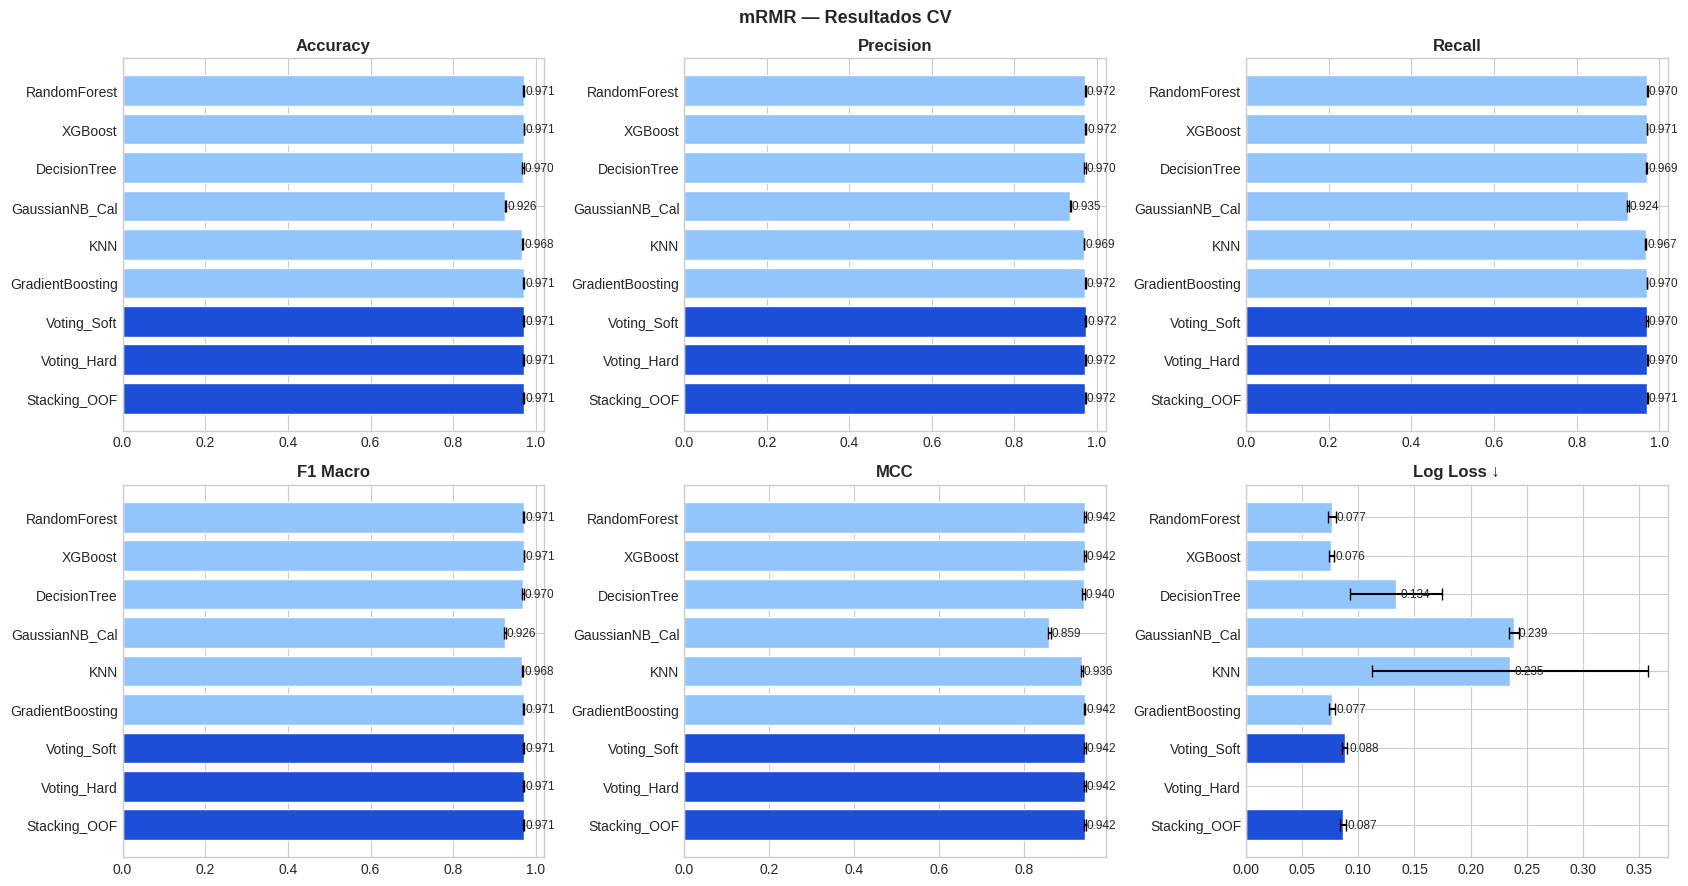


═════════════════════════════════════════════════════════════════
 Dataset: Fisher  (15 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] Fisher…
  [Fold 2/5] Fisher…
  [Fold 3/5] Fisher…
  [Fold 4/5] Fisher…
  [Fold 5/5] Fisher…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Fisher,RandomForest,0.971044,0.000946,0.971775,0.000884,0.970507,0.000991,0.970968,0.000952,0.942281,0.001845,0.076497,0.003423
1,Fisher,XGBoost,0.970822,0.000748,0.971497,0.000666,0.970308,0.000801,0.970747,0.000754,0.941805,0.001444,0.075986,0.002088
2,Fisher,DecisionTree,0.969585,0.001186,0.970535,0.000932,0.968949,0.001294,0.969497,0.001199,0.939483,0.002221,0.118364,0.018730
3,Fisher,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,Fisher,KNN,0.967704,0.001155,0.968629,0.000900,0.967077,0.001280,0.967611,0.001170,0.935705,0.002158,0.234856,0.122727
5,Fisher,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,Fisher,Voting_Soft,0.970927,0.001299,0.972193,0.001152,0.970170,0.001359,0.970833,0.001308,0.942361,0.002509,0.088033,0.002231
7,Fisher,Voting_Hard,0.971065,0.001128,0.971816,0.001016,0.970517,0.001187,0.970988,0.001136,0.942332,0.002190,NaN,NaN
8,Fisher,Stacking_OOF,0.971181,0.001076,0.971665,0.000834,0.970774,0.001209,0.971115,0.001089,0.942439,0.002028,0.086543,0.002596


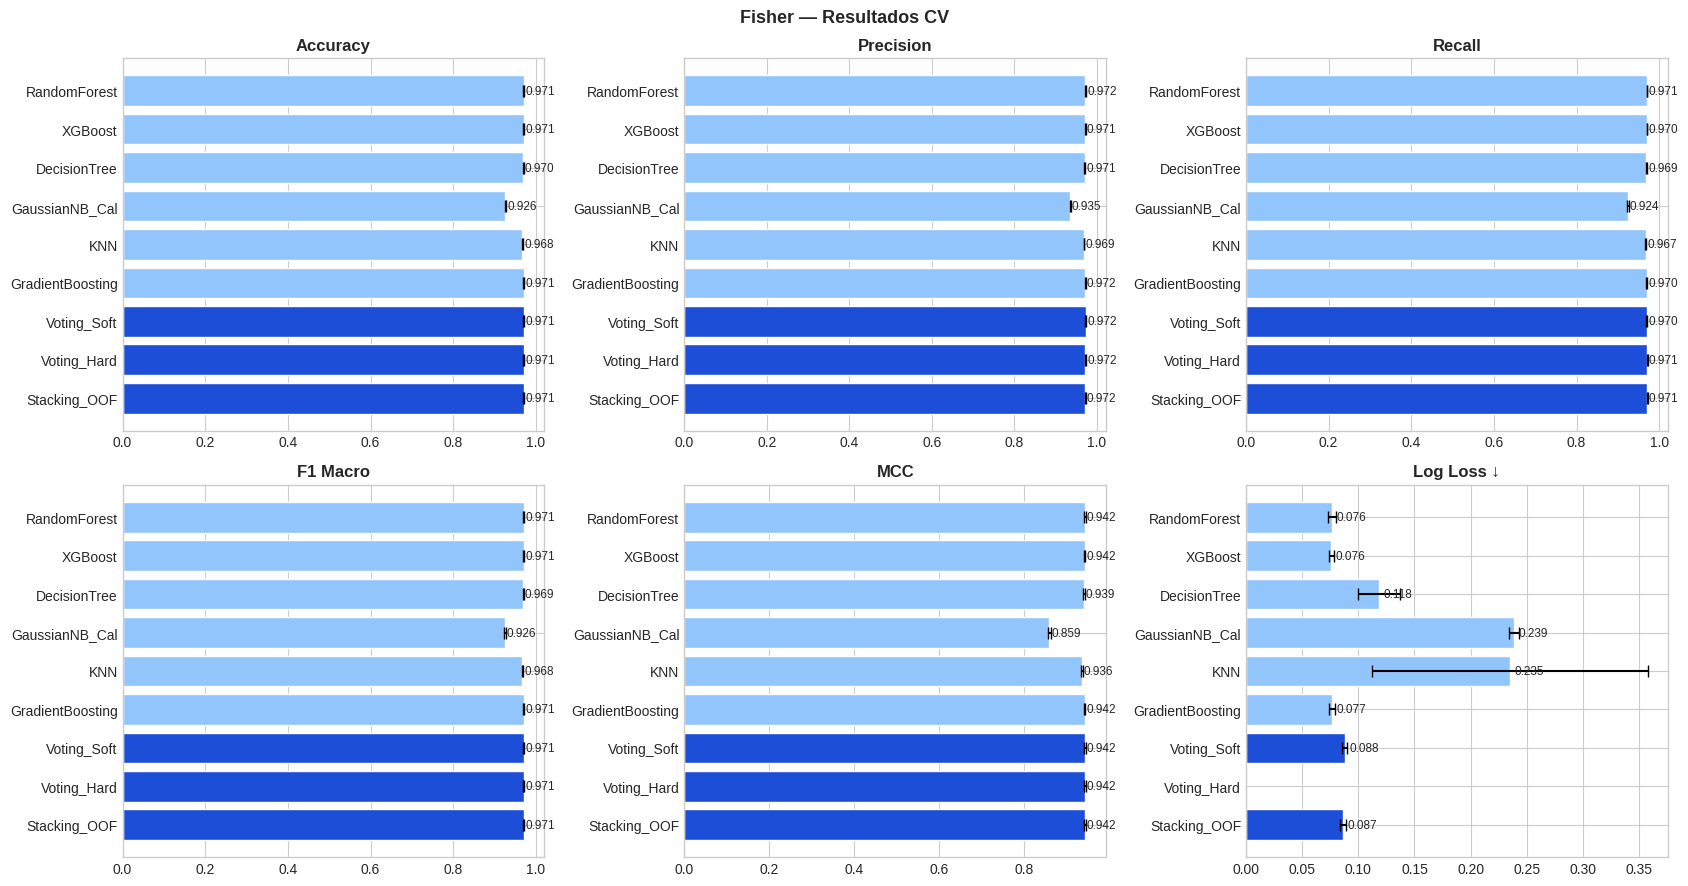


═════════════════════════════════════════════════════════════════
 Dataset: Pearson  (15 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] Pearson…
  [Fold 2/5] Pearson…
  [Fold 3/5] Pearson…
  [Fold 4/5] Pearson…
  [Fold 5/5] Pearson…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Pearson,RandomForest,0.971044,0.000946,0.971775,0.000884,0.970507,0.000991,0.970968,0.000952,0.942281,0.001845,0.076497,0.003423
1,Pearson,XGBoost,0.970822,0.000748,0.971497,0.000666,0.970308,0.000801,0.970747,0.000754,0.941805,0.001444,0.075986,0.002088
2,Pearson,DecisionTree,0.969585,0.001186,0.970535,0.000932,0.968949,0.001294,0.969497,0.001199,0.939483,0.002221,0.118364,0.018730
3,Pearson,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,Pearson,KNN,0.967704,0.001155,0.968629,0.000900,0.967077,0.001280,0.967611,0.001170,0.935705,0.002158,0.234856,0.122727
5,Pearson,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,Pearson,Voting_Soft,0.970927,0.001299,0.972193,0.001152,0.970170,0.001359,0.970833,0.001308,0.942361,0.002509,0.088033,0.002231
7,Pearson,Voting_Hard,0.971065,0.001128,0.971816,0.001016,0.970517,0.001187,0.970988,0.001136,0.942332,0.002190,NaN,NaN
8,Pearson,Stacking_OOF,0.971181,0.001076,0.971665,0.000834,0.970774,0.001209,0.971115,0.001089,0.942439,0.002028,0.086543,0.002596


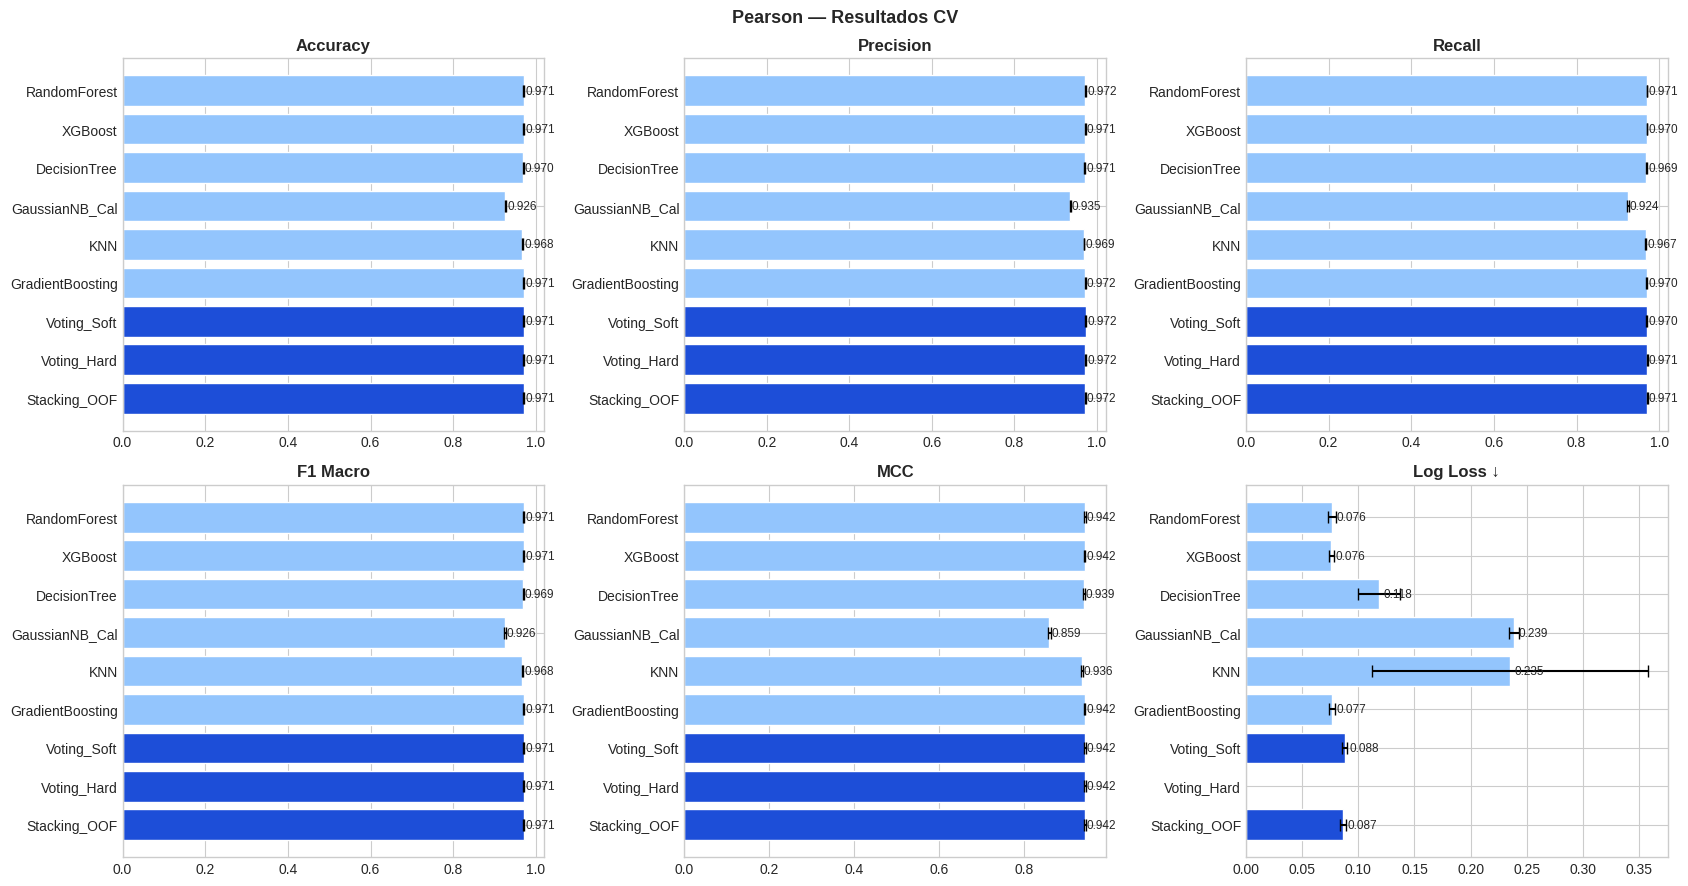


═════════════════════════════════════════════════════════════════
 Dataset: ExtraTrees  (15 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] ExtraTrees…
  [Fold 2/5] ExtraTrees…
  [Fold 3/5] ExtraTrees…
  [Fold 4/5] ExtraTrees…
  [Fold 5/5] ExtraTrees…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,ExtraTrees,RandomForest,0.971118,0.000914,0.971975,0.000824,0.970525,0.000969,0.971037,0.000921,0.942499,0.001765,0.076121,0.002884
1,ExtraTrees,XGBoost,0.971012,0.000643,0.971690,0.000613,0.970498,0.000676,0.970938,0.000647,0.942187,0.001258,0.076142,0.002243
2,ExtraTrees,DecisionTree,0.969606,0.000958,0.970313,0.000711,0.969095,0.001111,0.969528,0.000973,0.939407,0.001744,0.128907,0.038221
3,ExtraTrees,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,ExtraTrees,KNN,0.967704,0.001155,0.968629,0.000900,0.967077,0.001280,0.967611,0.001170,0.935705,0.002158,0.234856,0.122727
5,ExtraTrees,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,ExtraTrees,Voting_Soft,0.970843,0.001397,0.972068,0.001231,0.970100,0.001464,0.970749,0.001407,0.942166,0.002694,0.088187,0.002248
7,ExtraTrees,Voting_Hard,0.971202,0.001020,0.971944,0.000927,0.970660,0.001073,0.971126,0.001027,0.942602,0.001983,NaN,NaN
8,ExtraTrees,Stacking_OOF,0.971371,0.000890,0.971831,0.000845,0.970968,0.000932,0.971306,0.000895,0.942799,0.001761,0.086520,0.002582


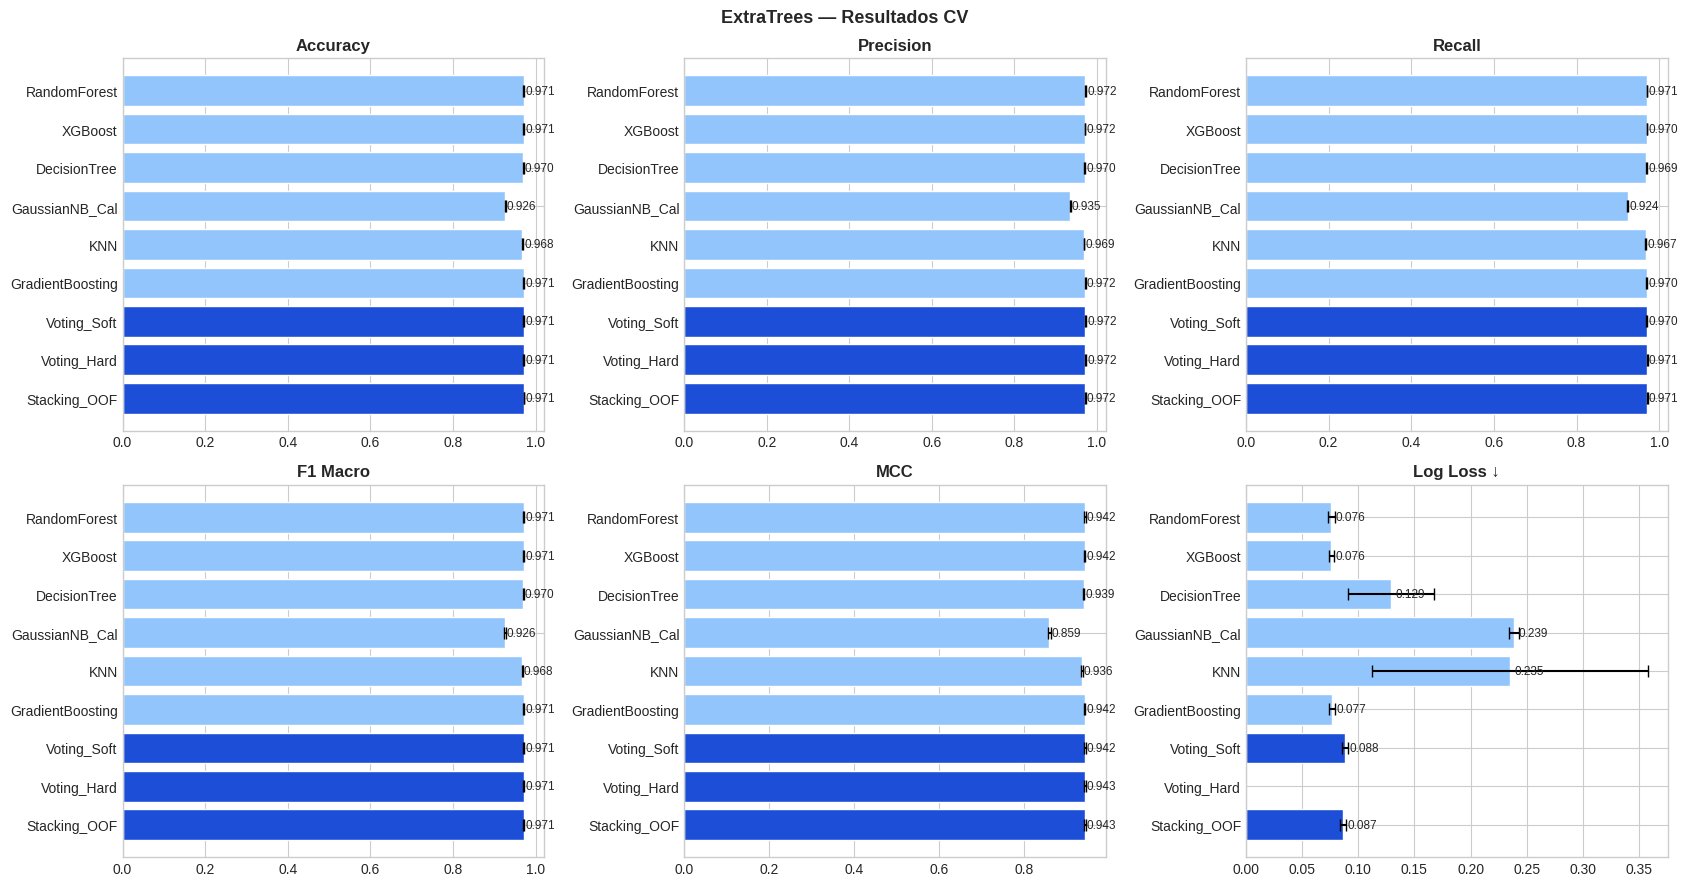


═════════════════════════════════════════════════════════════════
 Dataset: LinearSVC_L1  (15 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] LinearSVC_L1…
  [Fold 2/5] LinearSVC_L1…
  [Fold 3/5] LinearSVC_L1…
  [Fold 4/5] LinearSVC_L1…
  [Fold 5/5] LinearSVC_L1…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LinearSVC_L1,RandomForest,0.971107,0.001094,0.972014,0.000983,0.970492,0.001152,0.971025,0.001102,0.942505,0.002115,0.076478,0.002739
1,LinearSVC_L1,XGBoost,0.970991,0.000986,0.971643,0.000923,0.970488,0.001026,0.970917,0.000991,0.942130,0.001935,0.079144,0.007175
2,LinearSVC_L1,DecisionTree,0.970040,0.001071,0.970642,0.001095,0.969568,0.001086,0.969966,0.001075,0.940209,0.002137,0.122365,0.030603
3,LinearSVC_L1,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,LinearSVC_L1,KNN,0.967725,0.001152,0.968690,0.000892,0.967083,0.001279,0.967631,0.001166,0.935771,0.002147,0.236271,0.122018
5,LinearSVC_L1,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,LinearSVC_L1,Voting_Soft,0.971033,0.001256,0.972267,0.001123,0.970287,0.001309,0.970940,0.001264,0.942552,0.002431,0.088587,0.002483
7,LinearSVC_L1,Voting_Hard,0.971329,0.001086,0.972037,0.000990,0.970802,0.001140,0.971255,0.001093,0.942838,0.002116,NaN,NaN
8,LinearSVC_L1,Stacking_OOF,0.971181,0.001005,0.971521,0.000983,0.970844,0.001027,0.971120,0.001008,0.942365,0.002002,0.086589,0.002629


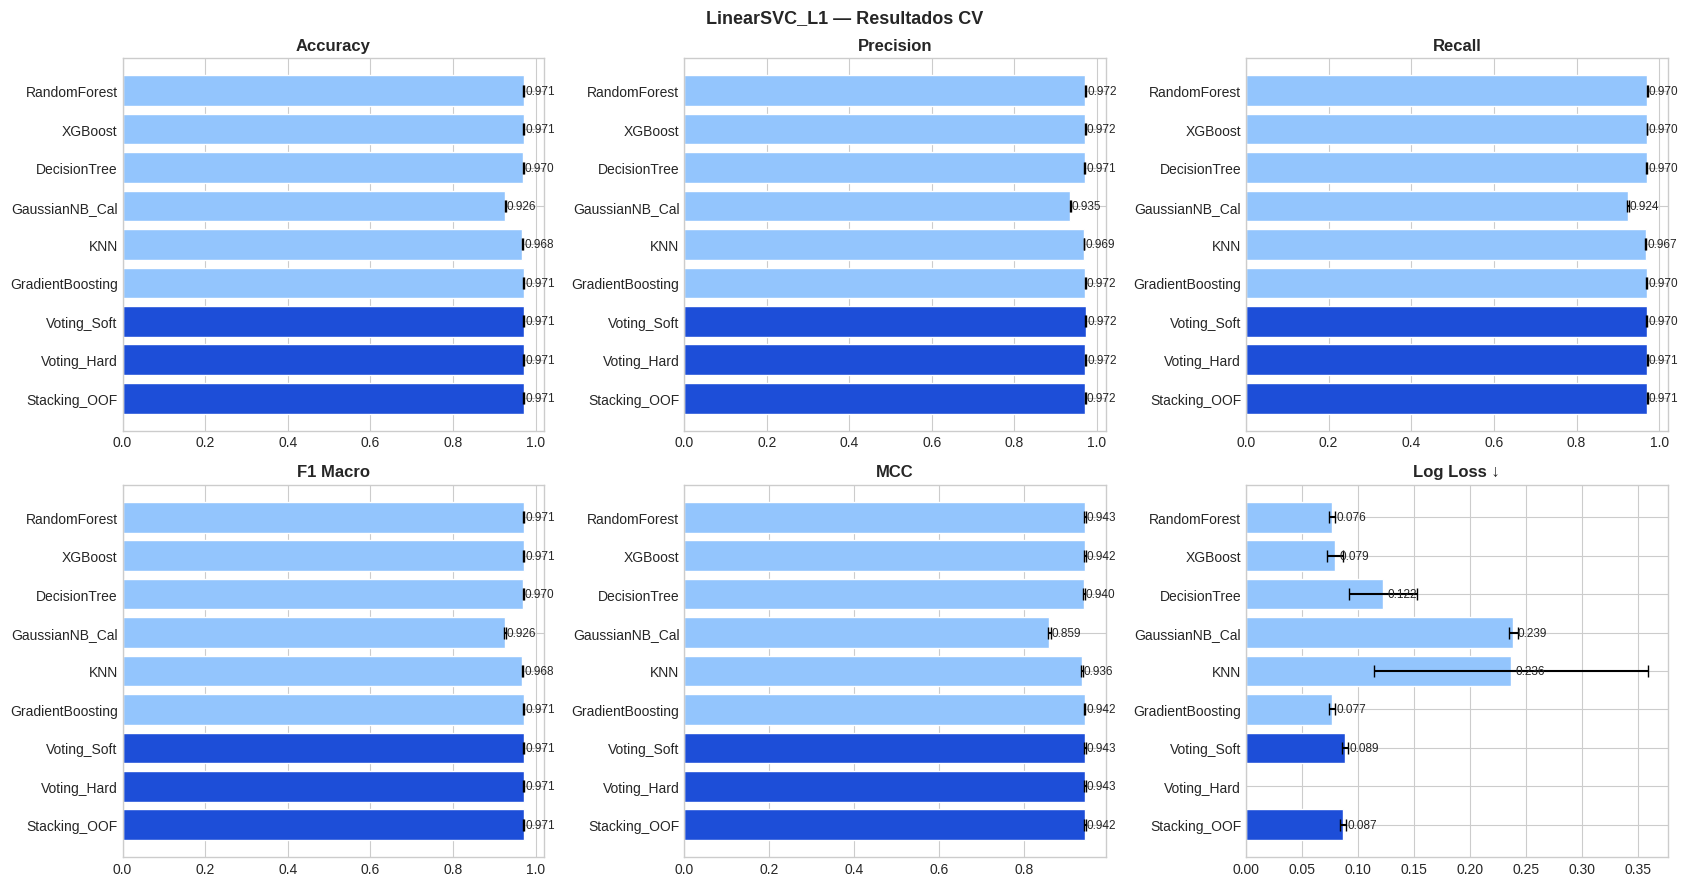


═════════════════════════════════════════════════════════════════
 Dataset: LassoCV  (15 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] LassoCV…
  [Fold 2/5] LassoCV…
  [Fold 3/5] LassoCV…
  [Fold 4/5] LassoCV…
  [Fold 5/5] LassoCV…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LassoCV,RandomForest,0.970938,0.000850,0.971951,0.000751,0.970279,0.000902,0.970852,0.000857,0.942228,0.001632,0.077838,0.003089
1,LassoCV,XGBoost,0.971096,0.000614,0.971866,0.000643,0.970539,0.000618,0.971019,0.000616,0.942405,0.001237,0.076223,0.002392
2,LassoCV,DecisionTree,0.970177,0.001143,0.970925,0.000869,0.969639,0.001276,0.970098,0.001158,0.940563,0.002110,0.175966,0.053882
3,LassoCV,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,LassoCV,KNN,0.967725,0.001152,0.968690,0.000892,0.967083,0.001279,0.967631,0.001166,0.935771,0.002147,0.236272,0.122018
5,LassoCV,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,LassoCV,Voting_Soft,0.971096,0.001404,0.972329,0.001251,0.970352,0.001465,0.971004,0.001414,0.942679,0.002715,0.088423,0.002411
7,LassoCV,Voting_Hard,0.971329,0.000865,0.972161,0.000763,0.970748,0.000927,0.971250,0.000872,0.942908,0.001663,NaN,NaN
8,LassoCV,Stacking_OOF,0.971192,0.000822,0.971539,0.000784,0.970851,0.000856,0.971131,0.000826,0.942389,0.001630,0.086550,0.002513


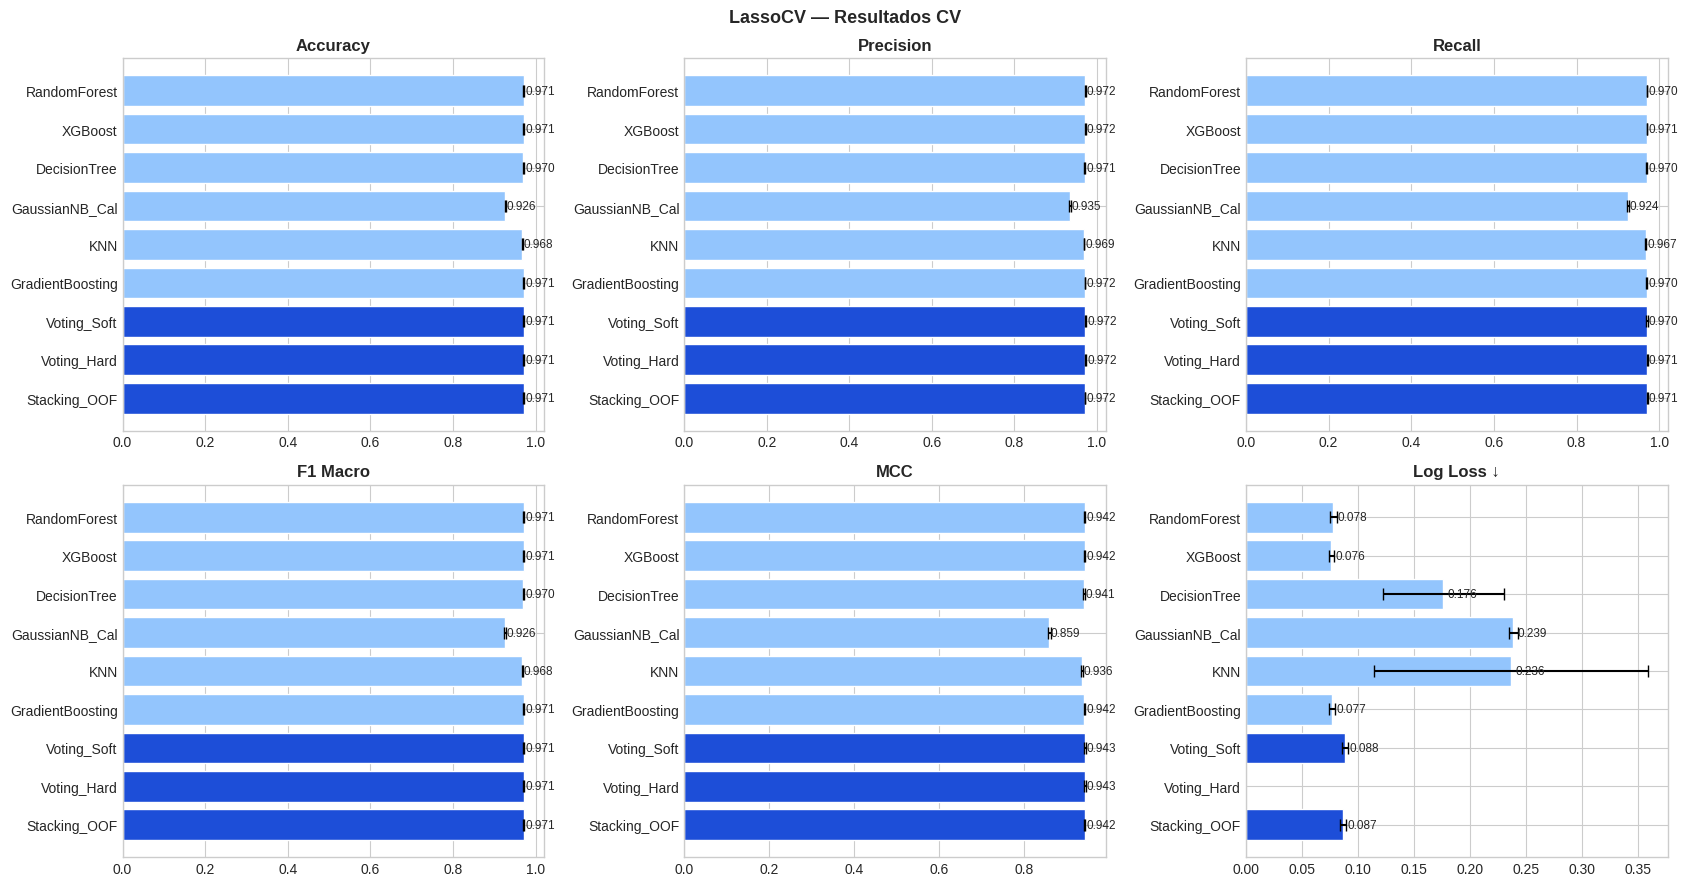


═════════════════════════════════════════════════════════════════
 Dataset: LowVariance  (14 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] LowVariance…
  [Fold 2/5] LowVariance…
  [Fold 3/5] LowVariance…
  [Fold 4/5] LowVariance…
  [Fold 5/5] LowVariance…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LowVariance,RandomForest,0.970991,0.000992,0.971735,0.000845,0.970450,0.001071,0.970914,0.001001,0.942183,0.001887,0.075765,0.002739
1,LowVariance,XGBoost,0.971118,0.000795,0.971874,0.000721,0.970568,0.000844,0.971041,0.000801,0.942441,0.001543,0.075969,0.002336
2,LowVariance,DecisionTree,0.969585,0.001370,0.970579,0.001228,0.968939,0.001454,0.969496,0.001381,0.939517,0.002632,0.123275,0.049895
3,LowVariance,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,LowVariance,KNN,0.967704,0.001155,0.968629,0.000900,0.967077,0.001280,0.967611,0.001170,0.935705,0.002158,0.234856,0.122727
5,LowVariance,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,LowVariance,Voting_Soft,0.971192,0.001223,0.972408,0.001082,0.970453,0.001279,0.971100,0.001231,0.942859,0.002361,0.088151,0.002139
7,LowVariance,Voting_Hard,0.971255,0.001008,0.972093,0.000879,0.970671,0.001077,0.971176,0.001016,0.942763,0.001938,NaN,NaN
8,LowVariance,Stacking_OOF,0.971318,0.001003,0.971972,0.000836,0.970826,0.001116,0.971246,0.001014,0.942798,0.001920,0.086870,0.002677


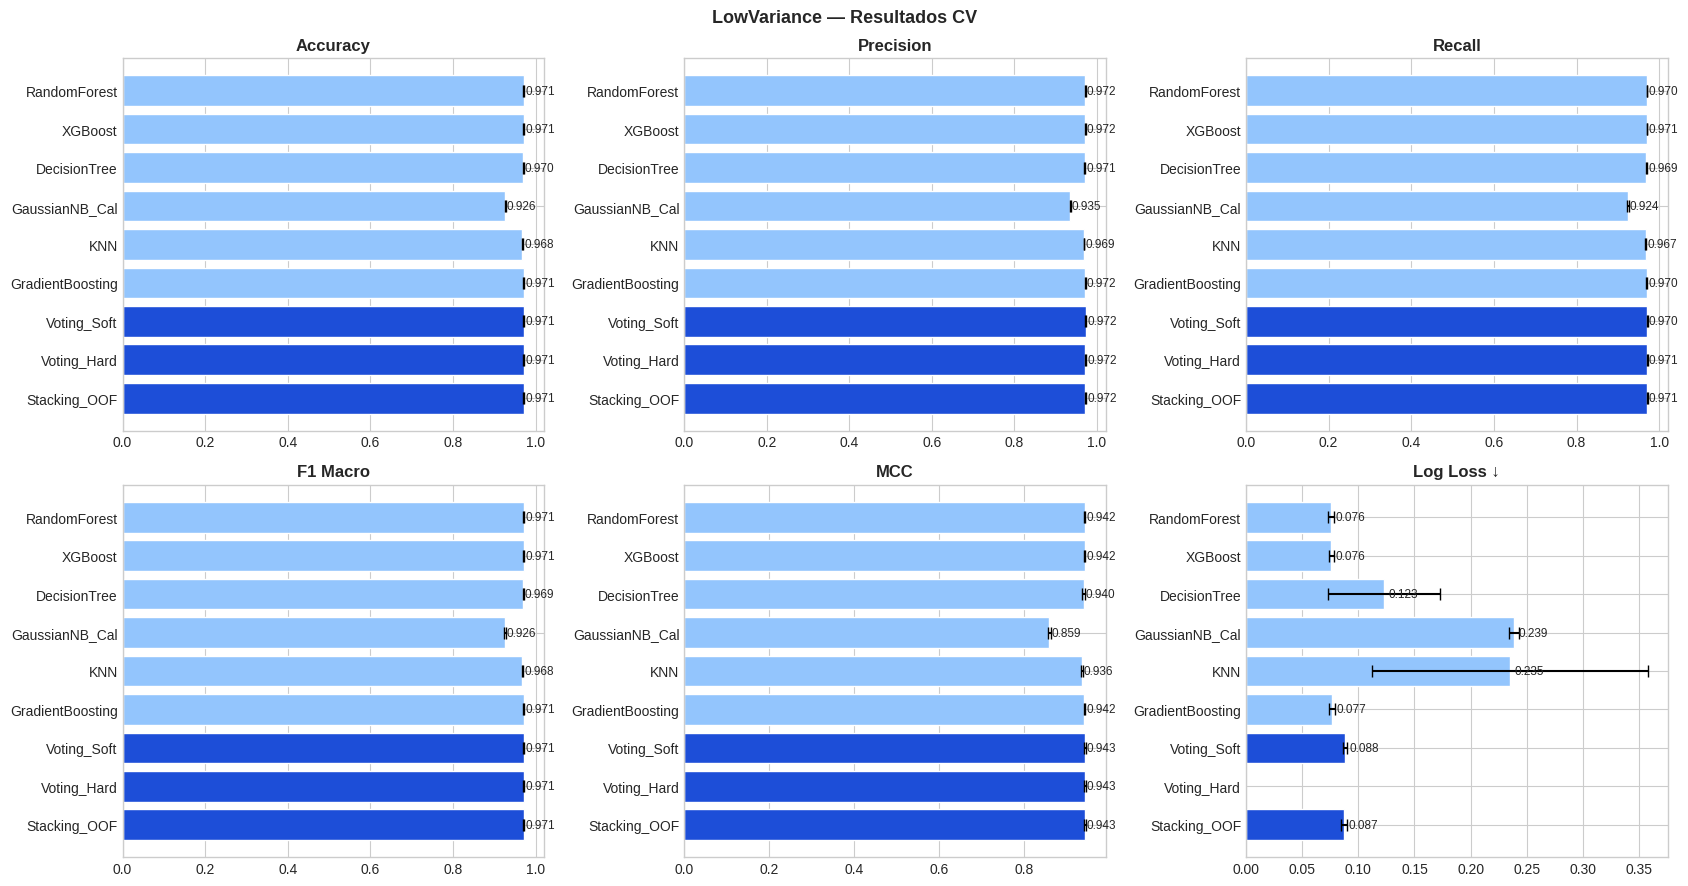


═════════════════════════════════════════════════════════════════
 Dataset: consensus_majority  (15 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] consensus_majority…
  [Fold 2/5] consensus_majority…
  [Fold 3/5] consensus_majority…
  [Fold 4/5] consensus_majority…
  [Fold 5/5] consensus_majority…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,consensus_majority,RandomForest,0.971234,0.001006,0.971956,0.000906,0.970705,0.001070,0.971159,0.001013,0.942660,0.001939,0.076147,0.002730
1,consensus_majority,XGBoost,0.971213,0.000641,0.972001,0.000672,0.970648,0.000642,0.971135,0.000642,0.942648,0.001290,0.076184,0.002449
2,consensus_majority,DecisionTree,0.969744,0.000776,0.970604,0.000572,0.969144,0.000868,0.969659,0.000786,0.939748,0.001430,0.137224,0.029506
3,consensus_majority,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,consensus_majority,KNN,0.967704,0.001155,0.968629,0.000900,0.967077,0.001280,0.967611,0.001170,0.935705,0.002158,0.234856,0.122727
5,consensus_majority,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,consensus_majority,Voting_Soft,0.970991,0.001373,0.972248,0.001231,0.970237,0.001431,0.970897,0.001382,0.942482,0.002660,0.087933,0.002119
7,consensus_majority,Voting_Hard,0.971234,0.001010,0.971975,0.000892,0.970690,0.001069,0.971158,0.001017,0.942665,0.001951,NaN,NaN
8,consensus_majority,Stacking_OOF,0.971149,0.000998,0.971557,0.000912,0.970774,0.001055,0.971086,0.001004,0.942330,0.001960,0.086629,0.002634


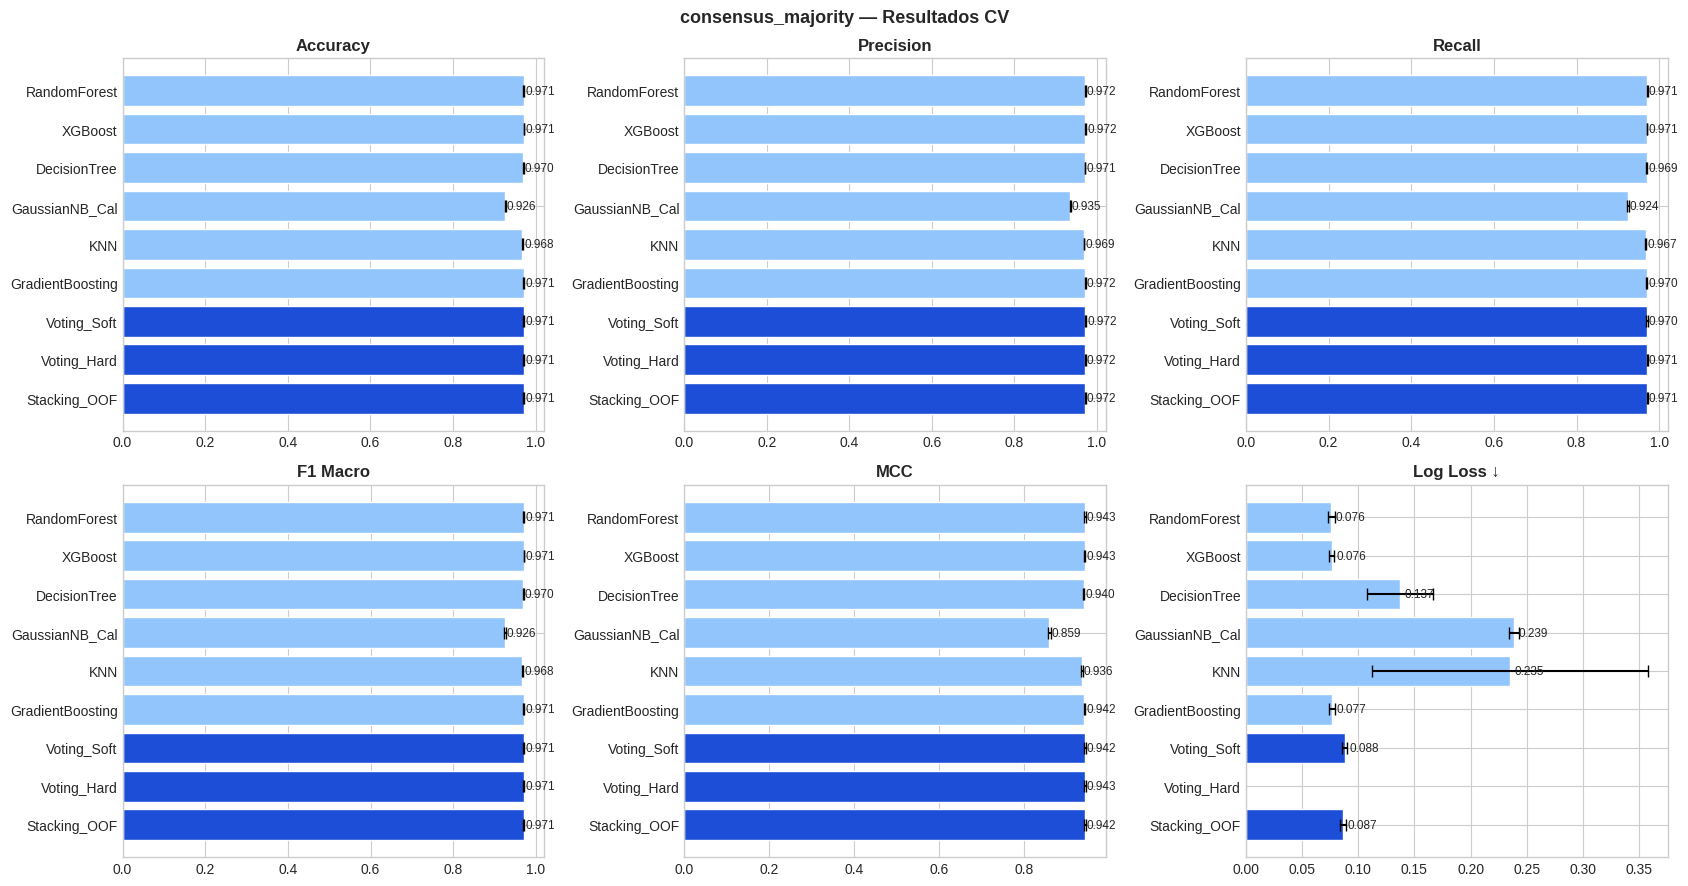


═════════════════════════════════════════════════════════════════
 Dataset: consensus_top15_rank  (15 features)
═════════════════════════════════════════════════════════════════
  [Fold 1/5] consensus_top15_rank…
  [Fold 2/5] consensus_top15_rank…
  [Fold 3/5] consensus_top15_rank…
  [Fold 4/5] consensus_top15_rank…
  [Fold 5/5] consensus_top15_rank…


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,consensus_top15_rank,RandomForest,0.971001,0.000996,0.971716,0.000893,0.970472,0.001055,0.970926,0.001003,0.942187,0.001926,0.076424,0.003346
1,consensus_top15_rank,XGBoost,0.970980,0.000517,0.971644,0.000519,0.970472,0.000536,0.970907,0.000520,0.942115,0.001021,0.078914,0.005124
2,consensus_top15_rank,DecisionTree,0.970092,0.001034,0.970790,0.001142,0.969573,0.001005,0.970016,0.001034,0.940362,0.002109,0.127219,0.028978
3,consensus_top15_rank,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
4,consensus_top15_rank,KNN,0.967704,0.001155,0.968629,0.000900,0.967077,0.001280,0.967611,0.001170,0.935705,0.002158,0.234856,0.122727
5,consensus_top15_rank,GradientBoosting,0.970705,0.000991,0.971529,0.000924,0.970125,0.001034,0.970625,0.000997,0.941653,0.001937,0.076643,0.002512
6,consensus_top15_rank,Voting_Soft,0.971054,0.001102,0.972244,0.000967,0.970325,0.001156,0.970963,0.001110,0.942567,0.002124,0.088488,0.002408
7,consensus_top15_rank,Voting_Hard,0.971234,0.000841,0.971953,0.000800,0.970701,0.000871,0.971159,0.000845,0.942653,0.001652,NaN,NaN
8,consensus_top15_rank,Stacking_OOF,0.971234,0.000879,0.971581,0.000822,0.970893,0.000922,0.971173,0.000883,0.942473,0.001737,0.086634,0.002566


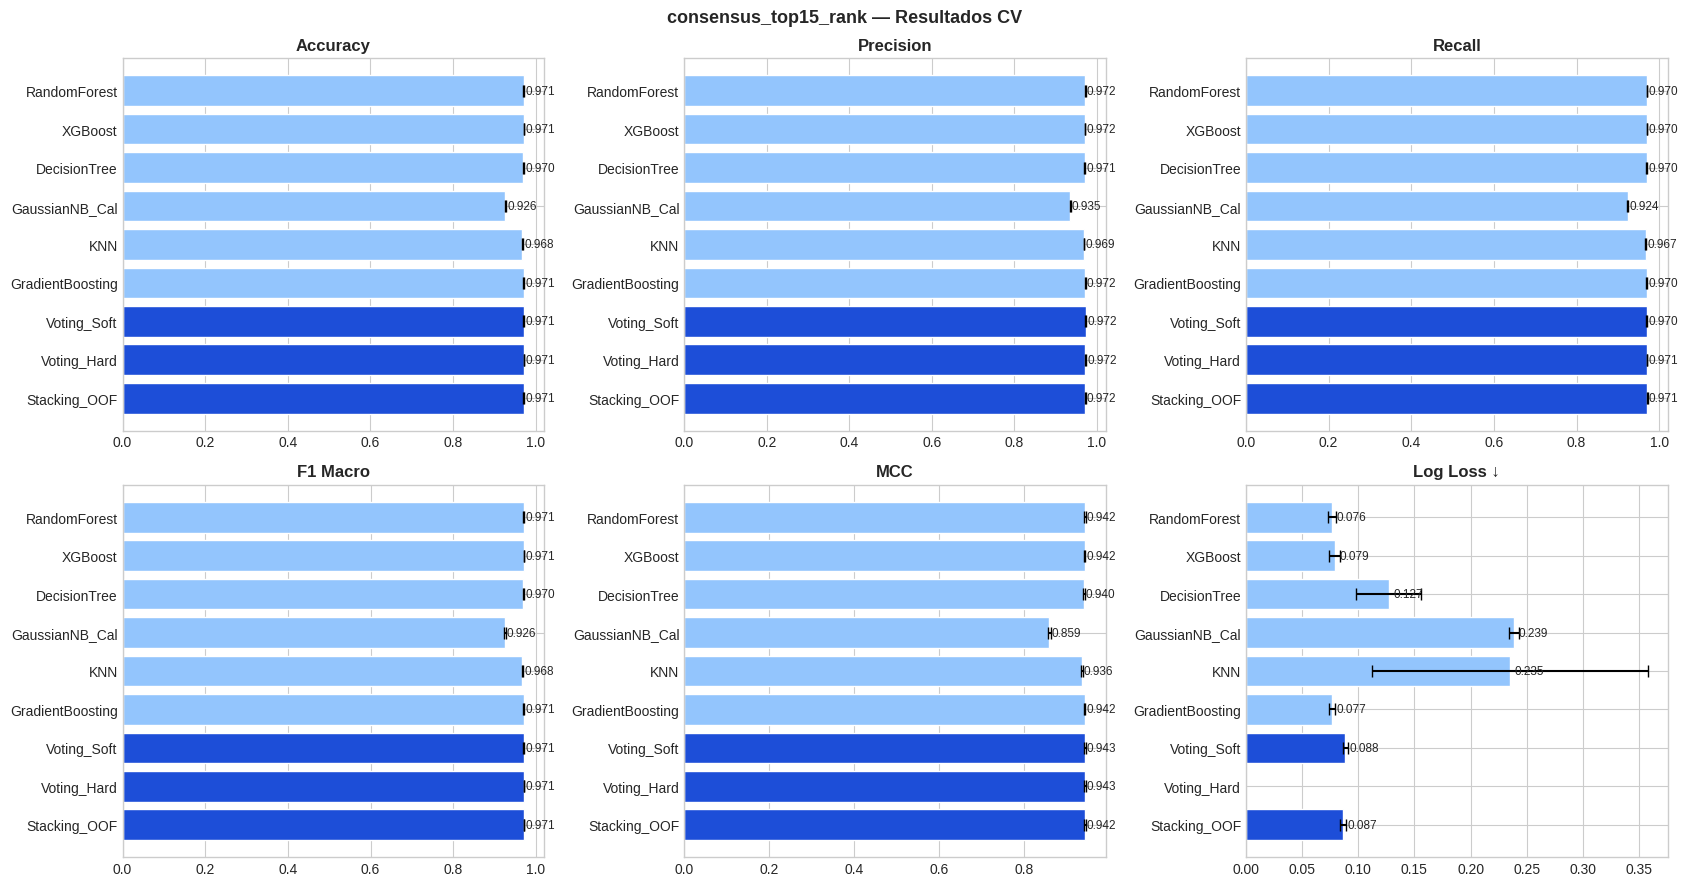


─────────────────────────────────────────────────────────────────
 COMPARAÇÃO GLOBAL: datasets × modelos
─────────────────────────────────────────────────────────────────


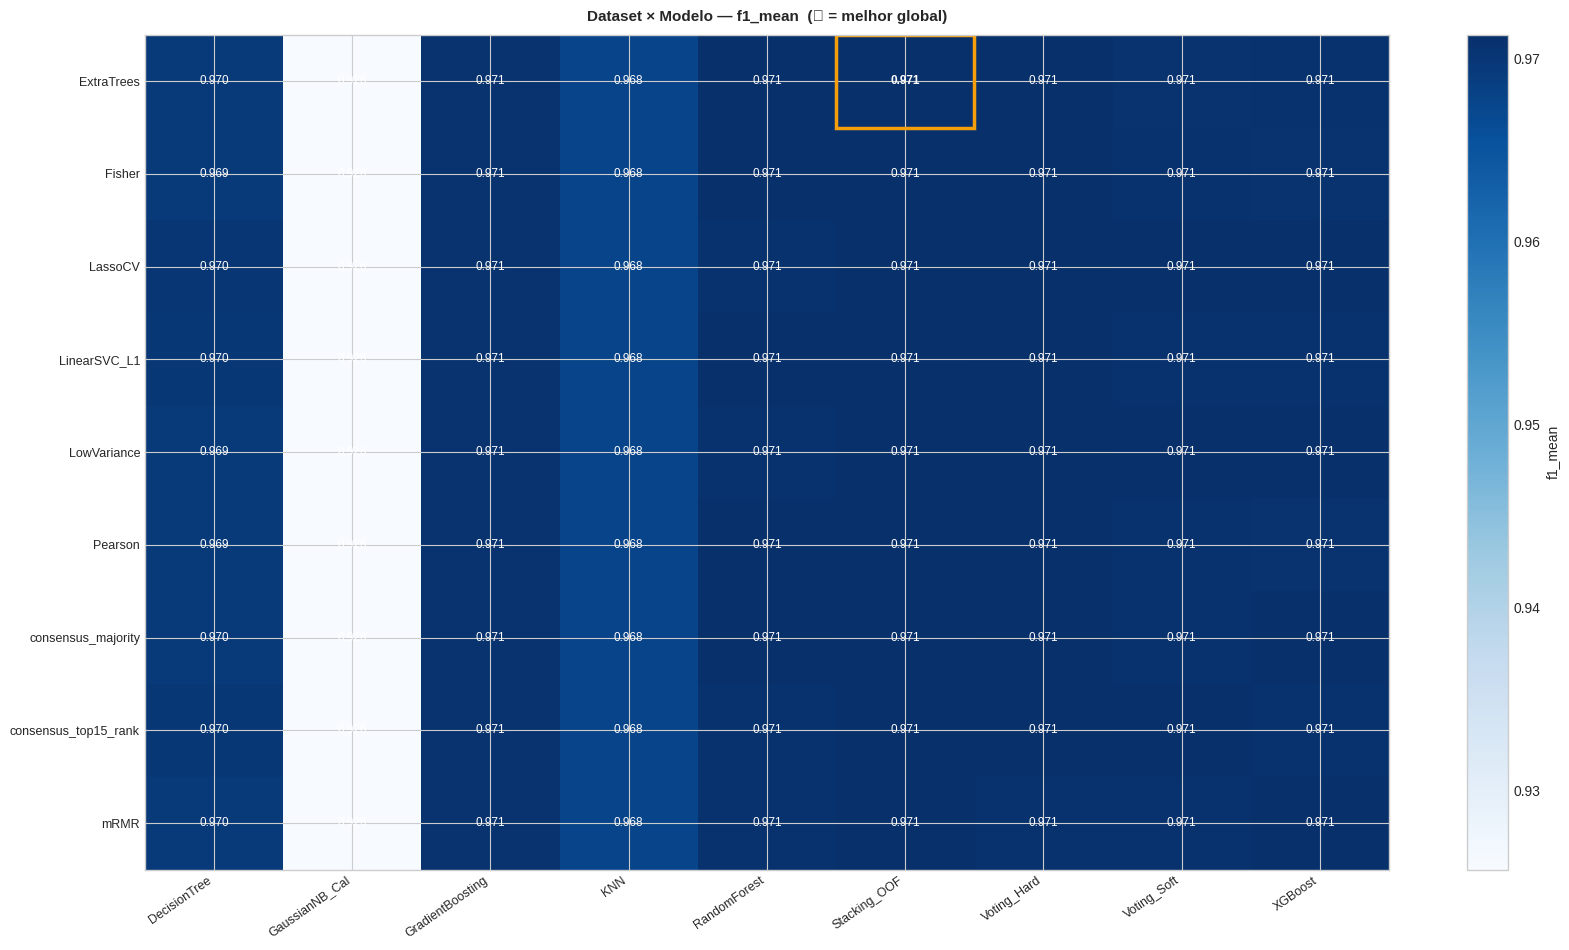


📊 Ganho Etapa 2 vs Baseline:
   Baseline melhor ensemble F1  : 0.97047
   Etapa 2  melhor ensemble F1  : 0.97131
   Delta                        : +0.00084

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  RESULTADO FINAL — métrica: f1_mean
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  [Melhor individual]
    Dataset (seletor) : consensus_majority
    Modelo            : RandomForest
    f1_mean               0.97116  (±0.00101)
    Todas as métricas:
      accuracy     0.97123
      precision    0.97196
      recall       0.97071
      f1           0.97116
      mcc          0.94266
      logloss      0.07615
    Hiperparâmetros (agregados entre folds):
      n_estimators                 330
      max_depth                    15
      min_samples_split            14
      min_samples_leaf             4
      max_features                 sqrt
      bootstrap                    1
      random_state                 42
      n_jobs     

,dataset,model,param,value
0,mRMR,RandomForest,n_estimators,300
1,mRMR,RandomForest,max_depth,13
2,mRMR,RandomForest,min_samples_split,11
3,mRMR,RandomForest,min_samples_leaf,6
4,mRMR,RandomForest,max_features,log2
...,...,...,...,...
373,consensus_top15_rank,GradientBoosting,max_depth,6
374,consensus_top15_rank,GradientBoosting,min_samples_leaf,25
375,consensus_top15_rank,GradientBoosting,l2_regularization,0.343551
376,consensus_top15_rank,GradientBoosting,max_bins,255


In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                   CONFIGURAÇÃO                                  ║
# ╚══════════════════════════════════════════════════════════════════╝
CV_SPLITS        = 5
N_OPTUNA_TRIALS  = 20  # TPE converge com 20 trials; 30 era excessivo
RANK_METRIC      = "f1_mean"

# Pasta para salvar CSVs dos datasets de features (None = não salva)
OUTPUT_DIR = None   # ex: "../data/processed/feature_sets"

# ── Executa Etapa 2 em todos os datasets ─────────────────────────
df_all, hyperparams_all = run_all_datasets(
    selector_datasets,
    y,
    cv_splits=CV_SPLITS,
    n_optuna_trials=N_OPTUNA_TRIALS,
)

# ── Heatmap comparativo global ────────────────────────────────────
print("\n" + "─"*65)
print(" COMPARAÇÃO GLOBAL: datasets × modelos")
print("─"*65)
plot_heatmap(df_all, metric=RANK_METRIC)

# ── Comparação Etapa 0 vs Etapa 2 (VotingClassifier) ─────────────
# Coleta o melhor resultado de cada etapa para o F1 do ensemble
best_etapa0_f1 = df_baseline["f1_macro"].max()
best_etapa2 = df_all[df_all["model"].isin({"Voting_Soft","Voting_Hard","Stacking_OOF"})]
if not best_etapa2.empty:
    best_etapa2_f1 = best_etapa2["f1_mean"].max()
    delta = best_etapa2_f1 - best_etapa0_f1
    print(f"\n📊 Ganho Etapa 2 vs Baseline:")
    print(f"   Baseline melhor ensemble F1  : {best_etapa0_f1:.5f}")
    print(f"   Etapa 2  melhor ensemble F1  : {best_etapa2_f1:.5f}")
    print(f"   Delta                        : {delta:+.5f}")

# ── Resultado final ───────────────────────────────────────────────
best_combo = find_best_combo(df_all, hyperparams_all, metric=RANK_METRIC)

# ── Tabela de hiperparâmetros ─────────────────────────────────────
print("\n── Hiperparâmetros agregados (seletor × modelo) ────────────")
display(summarize_hyperparams(hyperparams_all))

# ── Salva datasets se solicitado ─────────────────────────────────
if OUTPUT_DIR is not None:
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    for ds_name, X_ds in selector_datasets.items():
        path = Path(OUTPUT_DIR) / f"features_{ds_name}.csv"
        X_ds.to_csv(path, index=False)
        print(f"  Salvo: {path}")


In [10]:
from pathlib import Path

OUTPUT_DIR = "../data/processed/pipiline_fixed"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

for ds_name, X_ds in selector_datasets.items():
    path = Path(OUTPUT_DIR) / f"features_{ds_name}.csv"
    X_ds.to_csv(path, index=False)
    print(f"Salvo: {path}")

Salvo: ../data/processed/pipiline_fixed/features_mRMR.csv
Salvo: ../data/processed/pipiline_fixed/features_Fisher.csv
Salvo: ../data/processed/pipiline_fixed/features_Pearson.csv
Salvo: ../data/processed/pipiline_fixed/features_ExtraTrees.csv
Salvo: ../data/processed/pipiline_fixed/features_LinearSVC_L1.csv
Salvo: ../data/processed/pipiline_fixed/features_LassoCV.csv
Salvo: ../data/processed/pipiline_fixed/features_LowVariance.csv
Salvo: ../data/processed/pipiline_fixed/features_consensus_majority.csv
Salvo: ../data/processed/pipiline_fixed/features_consensus_top15_rank.csv
